# ***Black Friday Sale Prediction***
## *List of Features*:
1.List features which can help solving the purchase prediction on black friday sales
2.Perform basic EDA(Exploratory data Analysis) on the data.
3. List 3 characteristics you notice regarding the data
4.Apply Feature Engineering
5.Apply Feature Scaling
6.Select final feature

***Problem Statement:*** A retail company “ABC Private Limited” wants to understand the customer purchase behaviour (specifically, purchase amount) against various products of different categories. They have shared purchase summary of various customers for selected high volume products from last month. The data set also contains customer demographics (age, gender, marital status, city_type, stay_in_current_city), product details (product_id and product category) and Total purchase_amount from last month.

Now, they want to build a model to predict the purchase amount of customer against various products which will help them to create personalized offer for customers against different products.

## **Importing Libraries**

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**How big is the data**

In [6]:
df_train=pd.read_csv(r'blackfriday_train.csv.csv')
df_train.shape

(550068, 12)

In [7]:
df_test=pd.read_csv(r'blackfriday_test.csv.csv')
df_test.shape

(233599, 11)

**How does the data look like**

In [8]:
df_train.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [9]:
df_test.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,1000010,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,1000011,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


**What is the data type of columns**

In [10]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [11]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233599 entries, 0 to 233598
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     233599 non-null  int64  
 1   Product_ID                  233599 non-null  object 
 2   Gender                      233599 non-null  object 
 3   Age                         233599 non-null  object 
 4   Occupation                  233599 non-null  int64  
 5   City_Category               233599 non-null  object 
 6   Stay_In_Current_City_Years  233599 non-null  object 
 7   Marital_Status              233599 non-null  int64  
 8   Product_Category_1          233599 non-null  int64  
 9   Product_Category_2          161255 non-null  float64
 10  Product_Category_3          71037 non-null   float64
dtypes: float64(2), int64(4), object(5)
memory usage: 19.6+ MB


#### **Converting the dtype of ' Stay_In_Current_City_Years'**
(convert obj intto int)

In [12]:
df_train['Stay_In_Current_City_Years'] = df_train['Stay_In_Current_City_Years'].str.replace('+','')
df_train.head()

<ipython-input-12-000730376d83>:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df_train['Stay_In_Current_City_Years'] = df_train['Stay_In_Current_City_Years'].str.replace('+','')


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4,0,8,NaN,NaN,7969


In [13]:
df_train['Stay_In_Current_City_Years'] = df_train['Stay_In_Current_City_Years'].astype(int)
df_train.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4,0,8,NaN,NaN,7969


In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  int64  
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 50.4+ MB


In [15]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233599 entries, 0 to 233598
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     233599 non-null  int64  
 1   Product_ID                  233599 non-null  object 
 2   Gender                      233599 non-null  object 
 3   Age                         233599 non-null  object 
 4   Occupation                  233599 non-null  int64  
 5   City_Category               233599 non-null  object 
 6   Stay_In_Current_City_Years  233599 non-null  object 
 7   Marital_Status              233599 non-null  int64  
 8   Product_Category_1          233599 non-null  int64  
 9   Product_Category_2          161255 non-null  float64
 10  Product_Category_3          71037 non-null   float64
dtypes: float64(2), int64(4), object(5)
memory usage: 19.6+ MB


**How does the data look mathematically**

In [16]:
df_train.describe()

,User_ID,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,1.858418,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,1.289443,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,1.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,2.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,3.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,4.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


Maximum value for Occupation is 20 and mean value is around 8.07 The maximum purchase amount for the customers is 23961.0 whereas the minimum purchase amount is 12.0

In [17]:
df_test.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
count,2.335990e+05,233599.000000,233599.000000,233599.000000,161255.000000,71037.000000
mean,1.003029e+06,8.085407,0.410070,5.276542,9.849586,12.669454
std,1.726505e+03,6.521146,0.491847,3.736380,5.094943,4.125944
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000
25%,1.001527e+06,2.000000,0.000000,1.000000,5.000000,9.000000
50%,1.003070e+06,7.000000,0.000000,5.000000,9.000000,14.000000
75%,1.004477e+06,14.000000,1.000000,8.000000,15.000000,16.000000
max,1.006040e+06,20.000000,1.000000,18.000000,18.000000,18.000000


**Are there any duplicate values**

In [18]:
df_train.duplicated().sum()

0

In [19]:
df_test.duplicated().sum()

0

**Cleaning the data**

In [20]:
df_train=df_train.drop(['User_ID'],axis=1) #here axis=1 means vertically
df_train.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,P00285442,M,55+,16,C,4,0,8,NaN,NaN,7969


In [21]:
df_test=df_test.drop(['User_ID'],axis=1) #here axis=1 means vertically
df_test.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


###**Are there any Missing Values**

In [22]:
df_train.isnull().sum()

Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [23]:
df_train.isnull().mean()*100

Product_ID                     0.000000
Gender                         0.000000
Age                            0.000000
Occupation                     0.000000
City_Category                  0.000000
Stay_In_Current_City_Years     0.000000
Marital_Status                 0.000000
Product_Category_1             0.000000
Product_Category_2            31.566643
Product_Category_3            69.672659
Purchase                       0.000000
dtype: float64

Here we can see there are 31.56% missing values present in Product_Category_2  and 69.67% missing values present in Product_Category_3

In [24]:
df_test.isnull().sum()

Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2             72344
Product_Category_3            162562
dtype: int64

In [25]:
df_test.isnull().mean()*100

Product_ID                     0.000000
Gender                         0.000000
Age                            0.000000
Occupation                     0.000000
City_Category                  0.000000
Stay_In_Current_City_Years     0.000000
Marital_Status                 0.000000
Product_Category_1             0.000000
Product_Category_2            30.969311
Product_Category_3            69.590195
dtype: float64

## **Using Heatmap**
(to show the missing values in the dataset)

<Axes: >

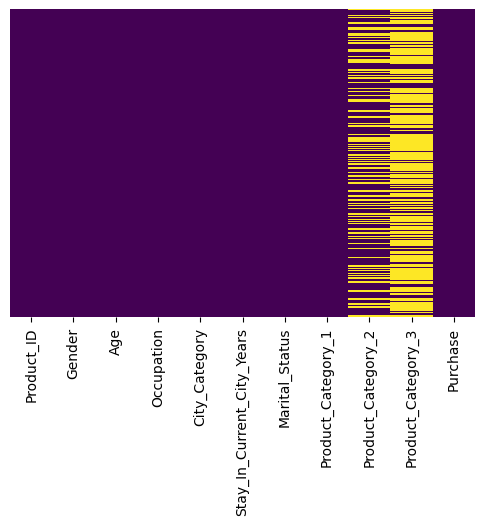

In [26]:
plt.figure(figsize=(6,4))
sns.heatmap(df_train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

<Axes: >

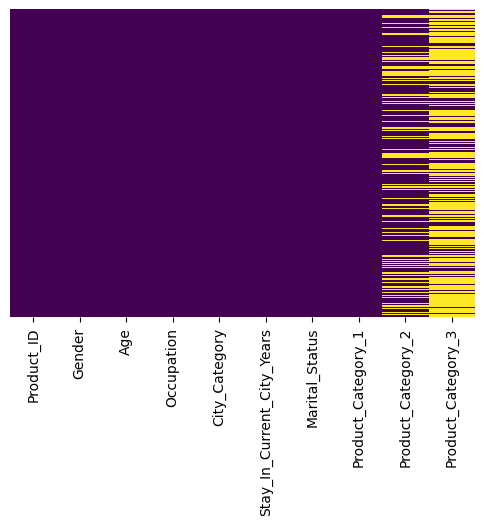

In [27]:
plt.figure(figsize=(6,4))
sns.heatmap(df_test.isnull(),yticklabels=False,cbar=False,cmap='viridis')

# ***Performing EDA***

## using Pairplot (to detect all numerical values and plot scatterplot)

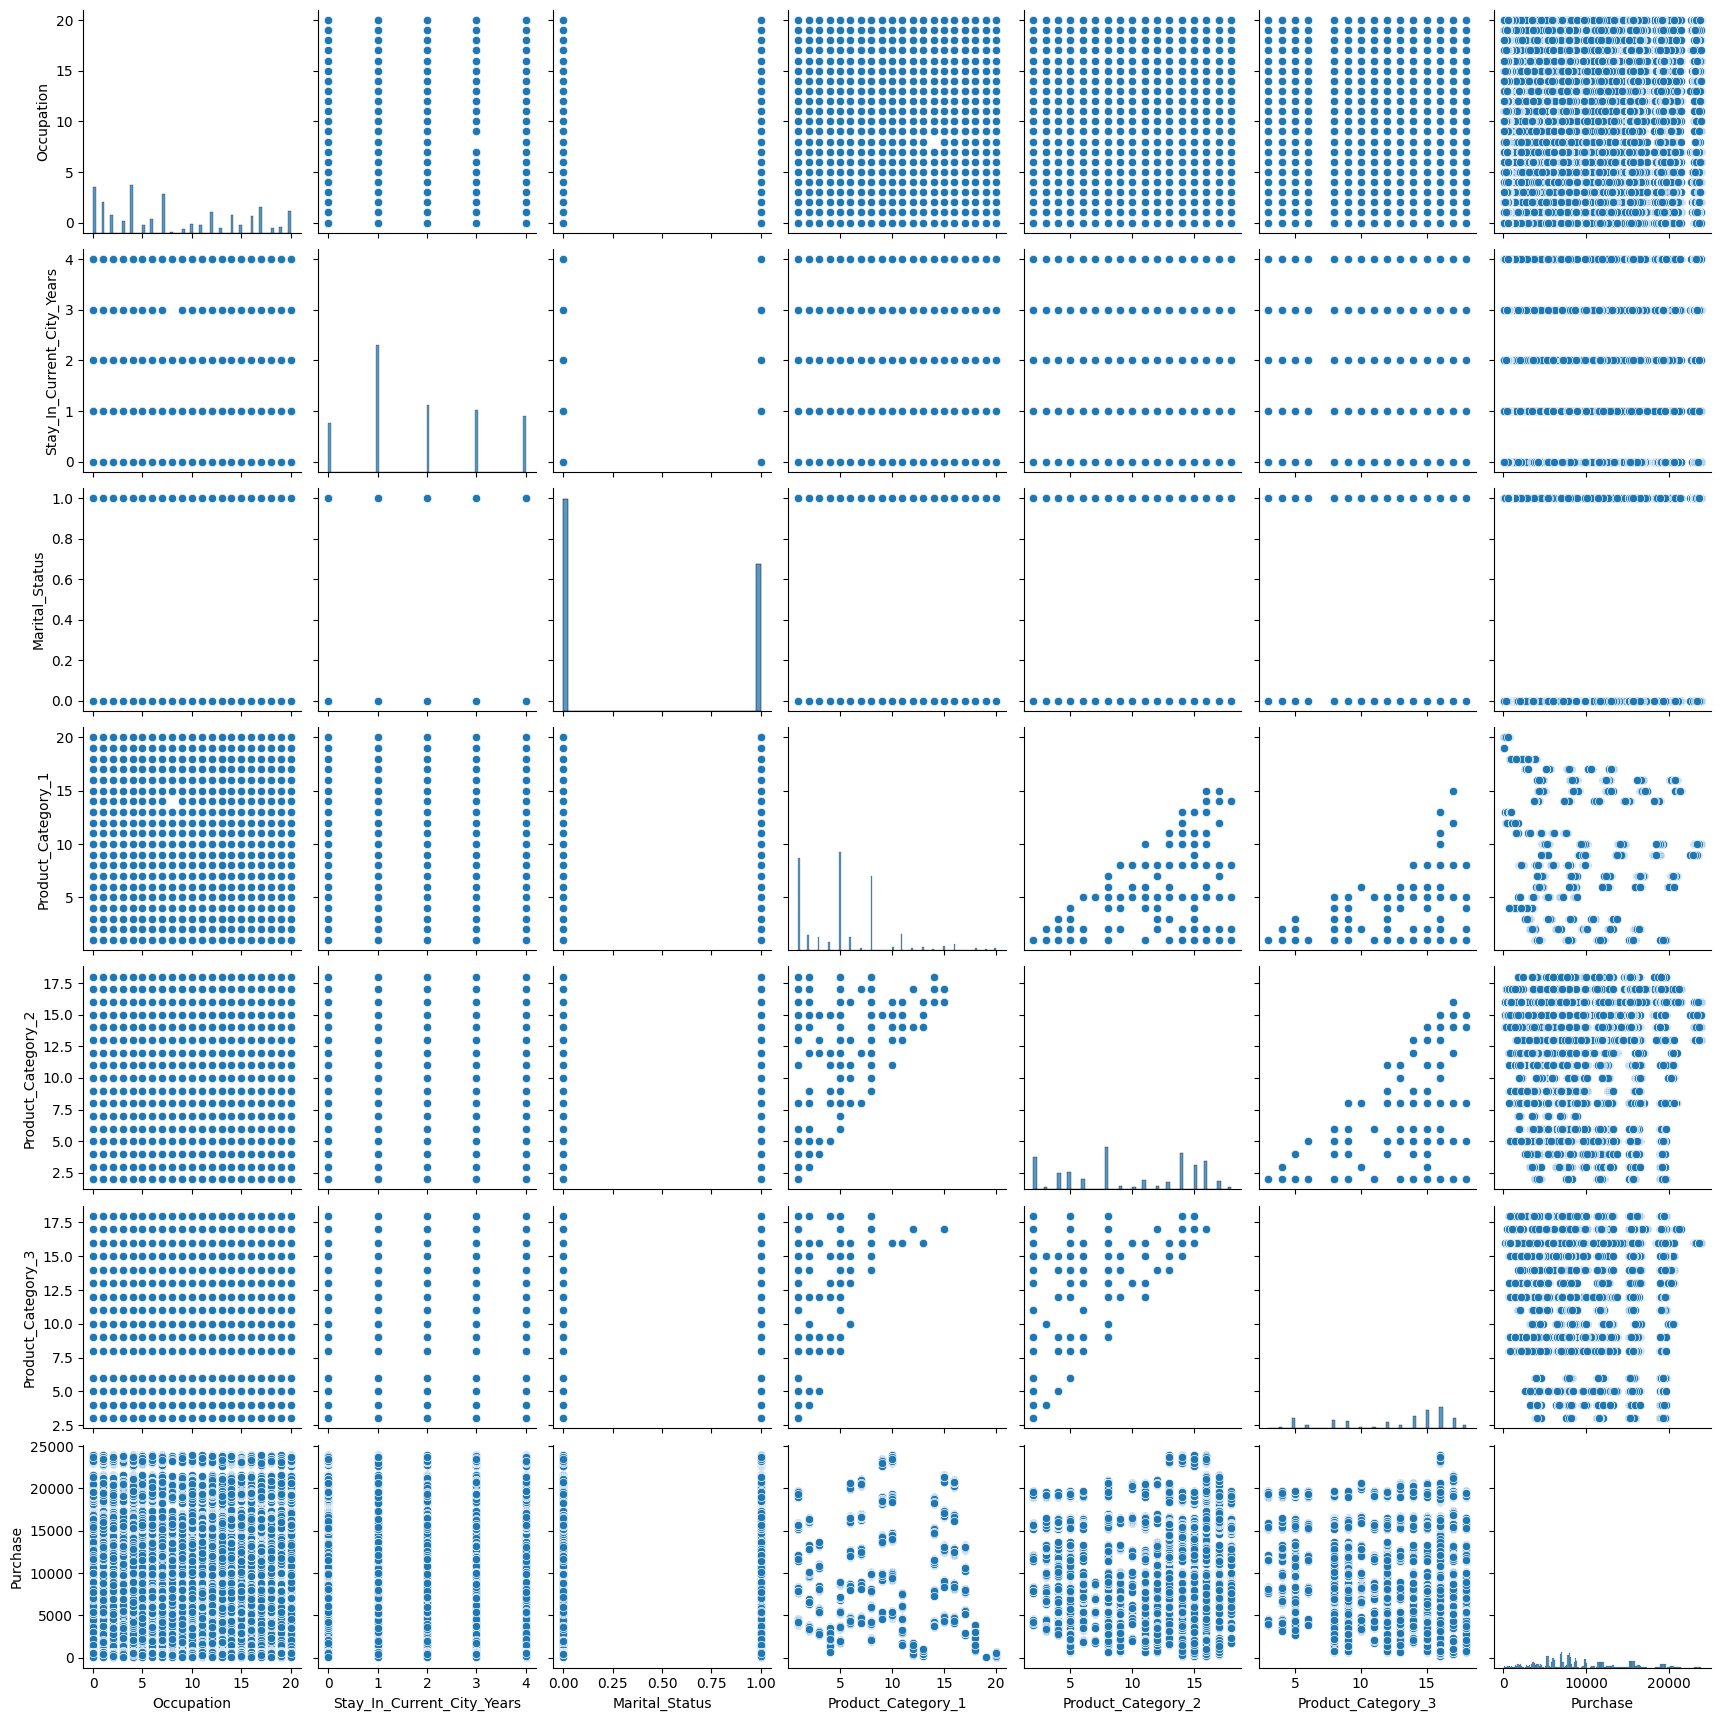

In [28]:
sns.pairplot(df_train)

From above analysis , we can understand that there are more categorical variable present than numerical .

<ipython-input-29-360ca0954555>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_train.corr(), annot = True)


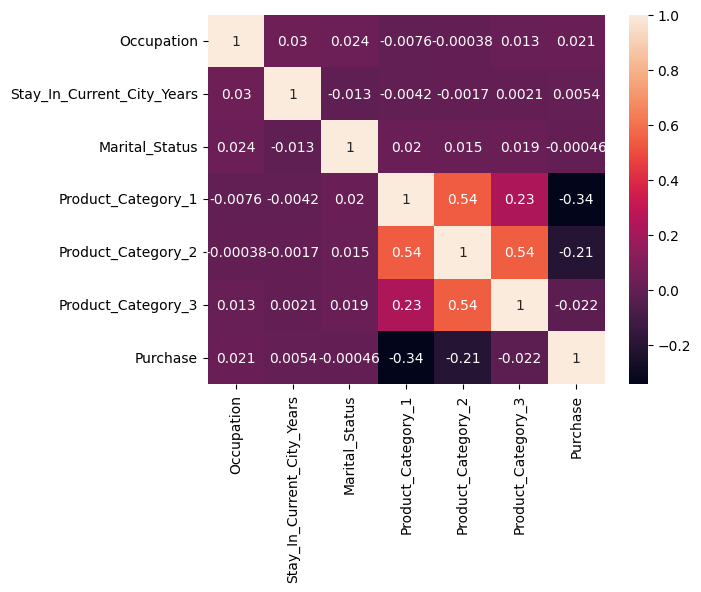

In [29]:
# Creating a heatmap of correlation matrix
sns.heatmap(df_train.corr(), annot = True)
plt.show()

Highly Correlated with Product_Category_1

## **Univariate Analysis**



*  **Categorical variable**
      
    *  Countplot
    *  Piechart




##using "countplot"
###for **Frequency Count** we are using "piechart"
####here we are using 'autopct=%.2f' to show the percentage

M    414259
F    135809
Name: Gender, dtype: int64


<ipython-input-30-cd77ca85098d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender',data=df_train,palette='husl')


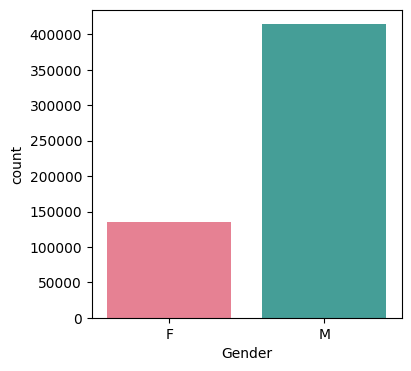

<Axes: ylabel='Gender'>

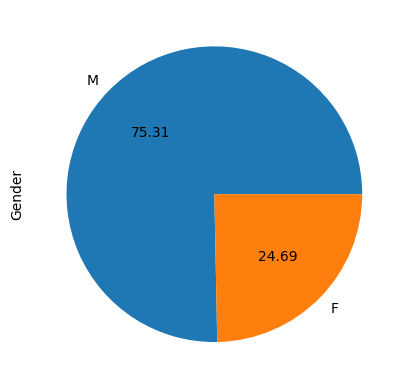

In [30]:
print(df_train['Gender'].value_counts())
plt.figure(figsize=(4,4))
sns.countplot(x='Gender',data=df_train,palette='husl')
plt.show()
df_train['Gender'].value_counts().plot(kind='pie',autopct='%.2f')

We observe that male customers have done more transactions than female customers during BlackFriday Sale.


B    231173
C    171175
A    147720
Name: City_Category, dtype: int64


<ipython-input-31-00651a4946bc>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='City_Category',data=df_train,palette='husl')


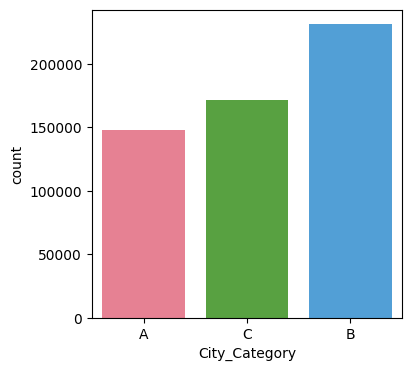

<Axes: ylabel='City_Category'>

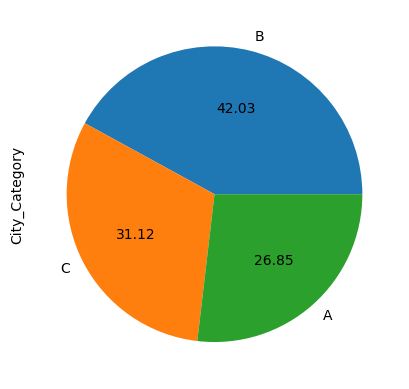

In [31]:
print(df_train['City_Category'].value_counts())
plt.figure(figsize=(4,4))
sns.countplot(x='City_Category',data=df_train,palette='husl')
plt.show()
df_train['City_Category'].value_counts().plot(kind='pie',autopct='%.2f')

We can see that B has made the most no. of purchases followed by c.

0    324731
1    225337
Name: Marital_Status, dtype: int64


<ipython-input-32-1fce9c38006d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Marital_Status',data=df_train,palette='plasma')


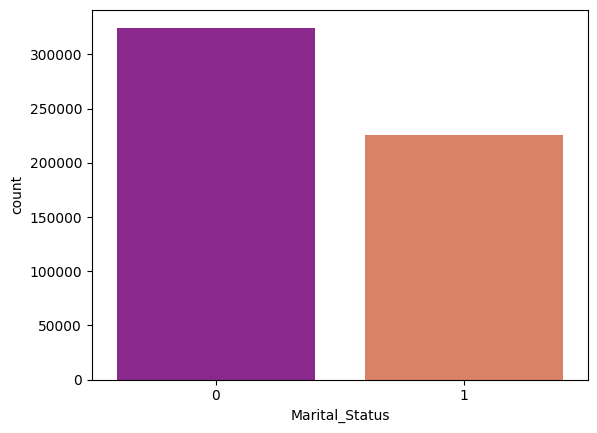

<Figure size 400x400 with 0 Axes>

<Axes: ylabel='Marital_Status'>

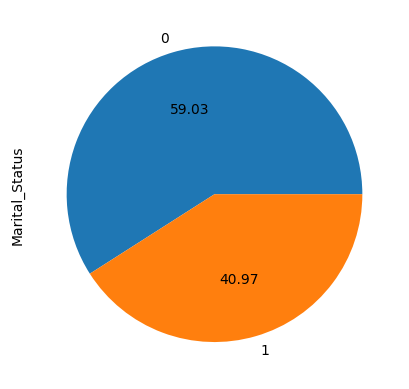

In [32]:
print(df_train['Marital_Status'].value_counts())
sns.countplot(x='Marital_Status',data=df_train,palette='plasma')
plt.figure(figsize=(4,4))
plt.show()
df_train['Marital_Status'].value_counts().plot(kind='pie',autopct='%.2f')

There are more unmarried customers who purchases more during BlackFriday Sale.

## **Bivariate Analysis**

#### Here we are doing Gaussian Distribution (Mean and Standard Deviation both are there) to analyse the Purchase distribution
### ('Purchase' is our Target Variable)

7011     191
7193     188
6855     187
6891     184
7012     183
        ... 
23491      1
18345      1
3372       1
855        1
21489      1
Name: Purchase, Length: 18105, dtype: int64


<ipython-input-33-729f73025eac>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'])


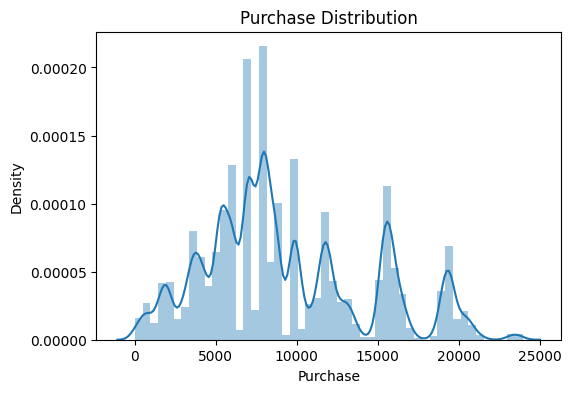

In [33]:
print(df_train['Purchase'].value_counts())

plt.figure(figsize=(6,4))
sns.distplot(df_train['Purchase'])
plt.title("Purchase Distribution")
plt.show()

we observe that purchase amount is repeating for many customers because of, on Black Friday many customers are buying discounted products in large numbers.

26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: Age, dtype: int64


<ipython-input-34-dba795922057>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age',data=df_train,palette='husl')


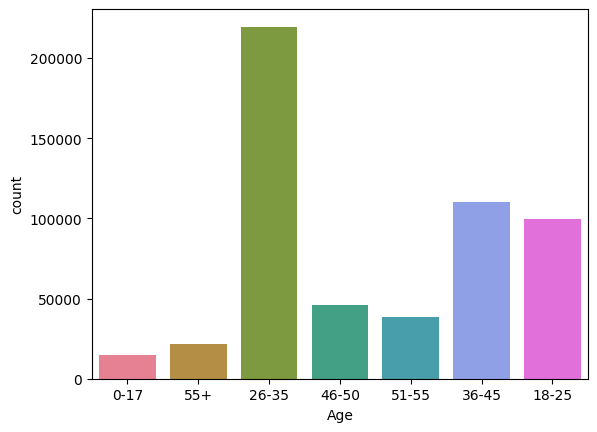

<Figure size 400x400 with 0 Axes>

In [34]:
print(df_train['Age'].value_counts())
sns.countplot(x='Age',data=df_train,palette='husl')
plt.figure(figsize=(4,4))
plt.show()

Here we observe that age between 26-35 has made more purchases

1    193821
2    101838
3     95285
4     84726
0     74398
Name: Stay_In_Current_City_Years, dtype: int64


<ipython-input-35-765a24d5b8dc>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Stay_In_Current_City_Years',data=df_train,palette='husl')


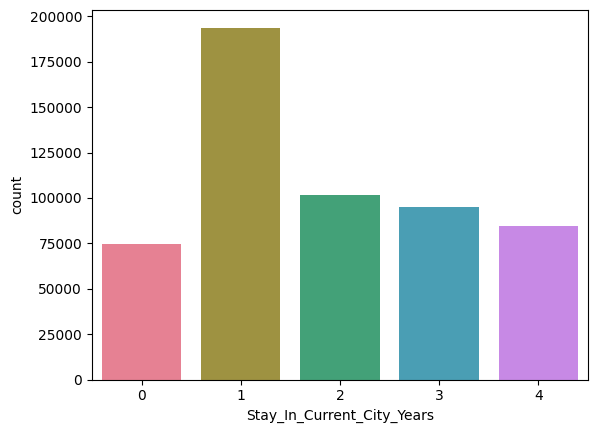

<Figure size 400x400 with 0 Axes>

In [35]:
print(df_train['Stay_In_Current_City_Years'].value_counts())
sns.countplot(x='Stay_In_Current_City_Years',data=df_train,palette='husl')
plt.figure(figsize=(4,4))
plt.show()

we can clearly see that the longest customers is living in that city are less prone to purchase but the newest customers in that city are more prone to buy new things during sale.

4     72308
0     69638
7     59133
1     47426
17    40043
20    33562
12    31179
14    27309
2     26588
16    25371
6     20355
3     17650
10    12930
5     12177
15    12165
11    11586
19     8461
13     7728
18     6622
9      6291
8      1546
Name: Occupation, dtype: int64


<ipython-input-36-70f9c60af9d1>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Occupation',data=df_train,palette='husl')


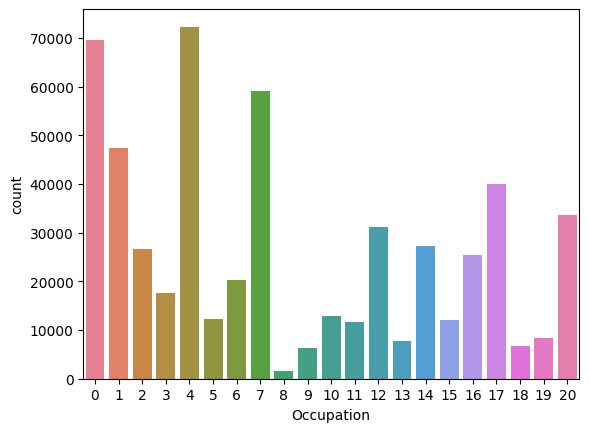

<Figure size 400x400 with 0 Axes>

In [36]:
print(df_train['Occupation'].value_counts())
sns.countplot(x='Occupation',data=df_train,palette='husl')
plt.figure(figsize=(4,4))
plt.show()

Customers whose occupations are 0 and 4 have done more transactions during Black Friday sales.

5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
13      5549
10      5125
12      3947
7       3721
18      3125
20      2550
19      1603
14      1523
17       578
9        410
Name: Product_Category_1, dtype: int64


<ipython-input-37-04032f400043>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Product_Category_1',data=df_train,palette='husl')


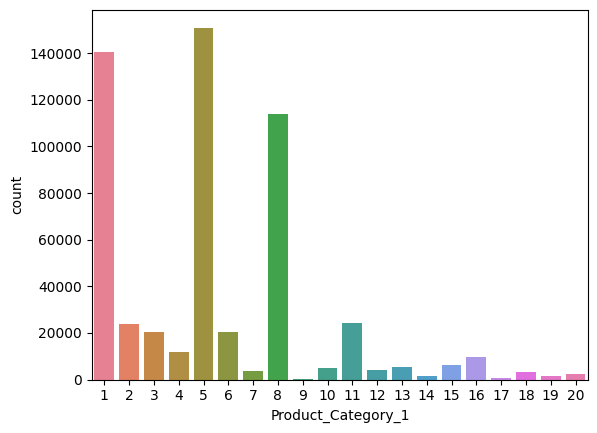

<Figure size 400x400 with 0 Axes>

In [37]:
print(df_train['Product_Category_1'].value_counts())
sns.countplot(x='Product_Category_1',data=df_train,palette='husl')
plt.figure(figsize=(4,4))
plt.show()

we observe that for product_category1  1,5 and 8 have made the more purchases during BlackFriday Sale

8.0     64088
14.0    55108
2.0     49217
16.0    43255
15.0    37855
5.0     26235
4.0     25677
6.0     16466
11.0    14134
17.0    13320
13.0    10531
9.0      5693
12.0     5528
10.0     3043
3.0      2884
18.0     2770
7.0       626
Name: Product_Category_2, dtype: int64


<ipython-input-38-1bd8932c0352>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Product_Category_2',data=df_train,palette='husl')


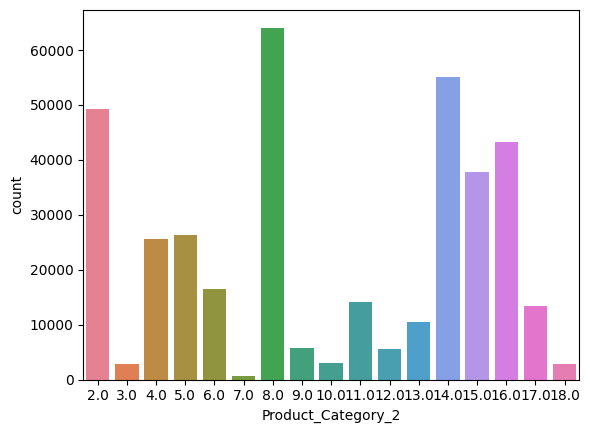

<Figure size 400x400 with 0 Axes>

In [38]:
print(df_train['Product_Category_2'].value_counts())
sns.countplot(x='Product_Category_2',data=df_train,palette='husl')
plt.figure(figsize=(4,4))
plt.show()

we observe that 8 has made more purchase during BlackFriday Sale

16.0    32636
15.0    28013
14.0    18428
17.0    16702
5.0     16658
8.0     12562
9.0     11579
12.0     9246
13.0     5459
6.0      4890
18.0     4629
4.0      1875
11.0     1805
10.0     1726
3.0       613
Name: Product_Category_3, dtype: int64


<ipython-input-39-04d76210ae95>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Product_Category_3',data=df_train,palette='husl')


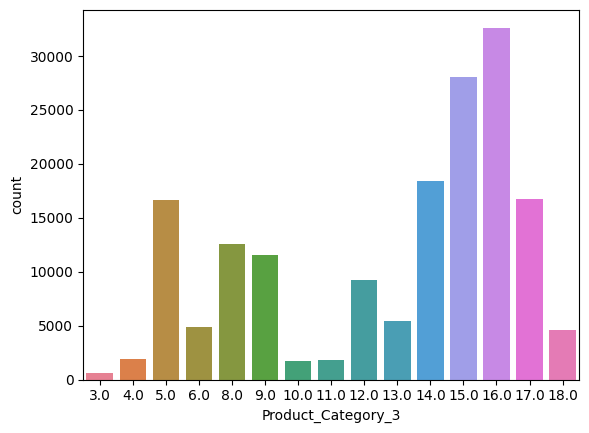

<Figure size 400x400 with 0 Axes>

In [39]:
print(df_train['Product_Category_3'].value_counts())
sns.countplot(x='Product_Category_3',data=df_train,palette='husl')
plt.figure(figsize=(4,4))
plt.show()

we observe that 16 has made more purchase during BlackFriday Sale


## **Using Heatmap**

<Axes: xlabel='Marital_Status', ylabel='Purchase'>

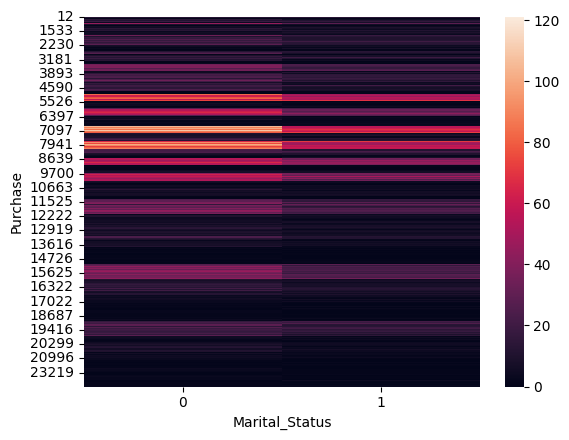

In [40]:
sns.heatmap(pd.crosstab(df_train['Purchase'],df_train['Marital_Status']))

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='Purchase'>

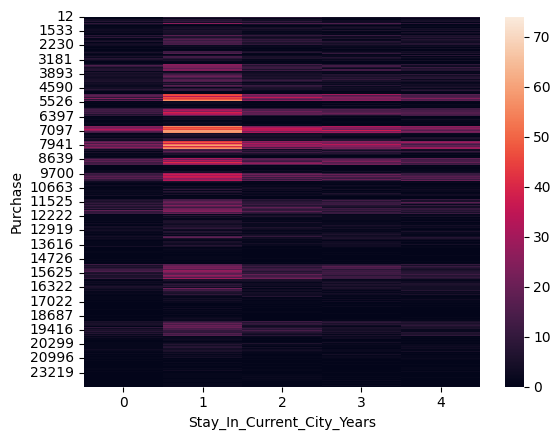

In [41]:
sns.heatmap(pd.crosstab(df_train['Purchase'],df_train['Stay_In_Current_City_Years']))

<Axes: xlabel='Purchase', ylabel='Gender'>

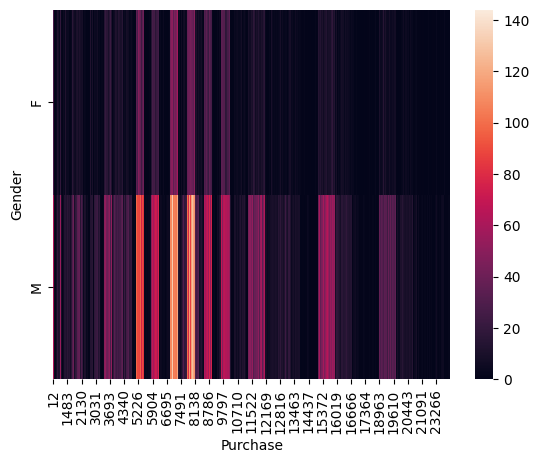

In [42]:
sns.heatmap(pd.crosstab(df_train['Gender'],df_train['Purchase']))

<Axes: xlabel='Purchase', ylabel='City_Category'>

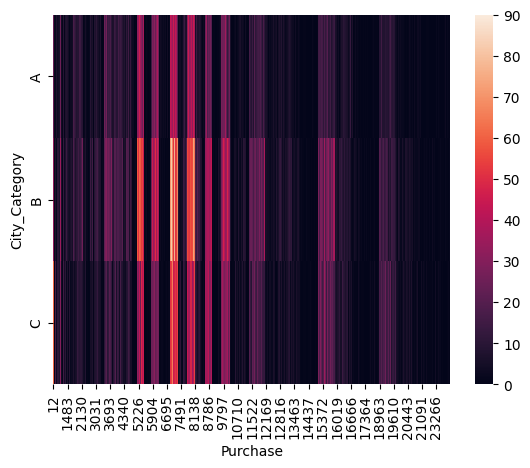

In [43]:
sns.heatmap(pd.crosstab(df_train['City_Category'],df_train['Purchase']))

From the above analysis,among male and female customers we observe that B has spent more.

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

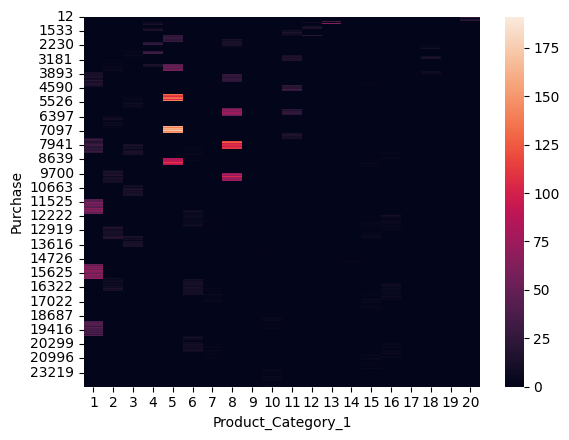

In [44]:
sns.heatmap(pd.crosstab(df_train['Purchase'],df_train['Product_Category_1']))

<Axes: xlabel='Product_Category_2', ylabel='Purchase'>

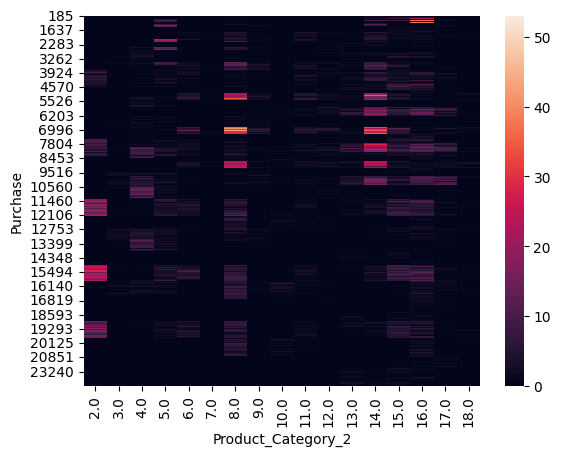

In [45]:
sns.heatmap(pd.crosstab(df_train['Purchase'],df_train['Product_Category_2']))

<Axes: xlabel='Product_Category_3', ylabel='Purchase'>

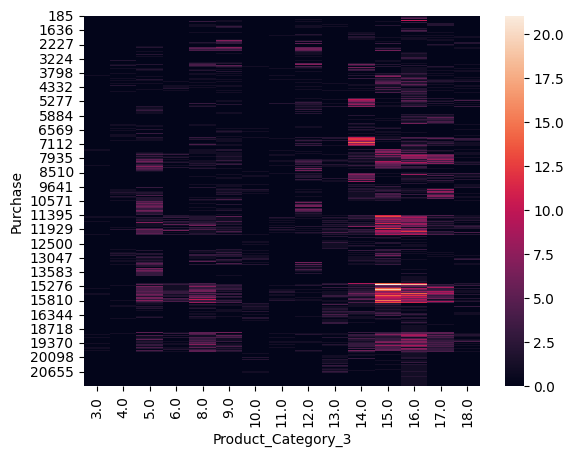

In [46]:
sns.heatmap(pd.crosstab(df_train['Purchase'],df_train['Product_Category_3']))

##**Numerical-Categorical**



*  Barplot(using groupby())
*  Boxplot




<ipython-input-47-4ff6945fe8af>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_train.groupby('City_Category').mean()['Purchase'].plot(kind='bar')


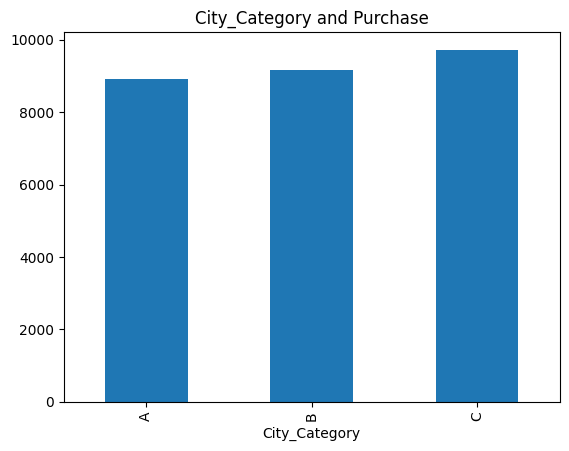

In [47]:
df_train.groupby('City_Category').mean()['Purchase'].plot(kind='bar')
plt.title('City_Category and Purchase')
plt.show()

we observe that c has spent more during BlackFriday Sale

<ipython-input-48-523f81e246c3>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_train.groupby('Gender').mean()['Purchase'].plot(kind='bar')


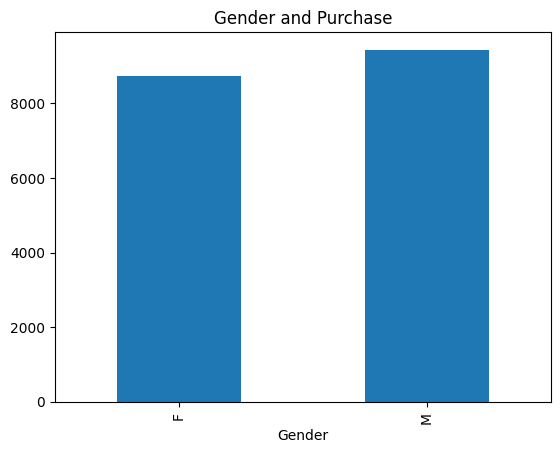

In [48]:
df_train.groupby('Gender').mean()['Purchase'].plot(kind='bar')
plt.title('Gender and Purchase')
plt.show()

<ipython-input-49-b3eb46c77aae>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_train.groupby('Marital_Status').mean()['Purchase'].plot(kind='bar')


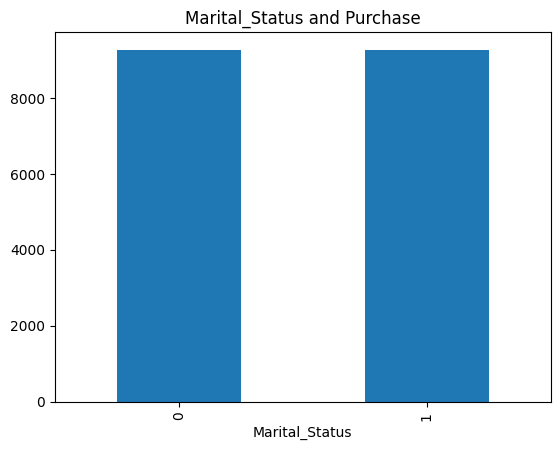

In [49]:
df_train.groupby('Marital_Status').mean()['Purchase'].plot(kind='bar')
plt.title('Marital_Status and Purchase')
plt.show()

<ipython-input-50-e5cafa879203>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_train.groupby('Stay_In_Current_City_Years').mean()['Purchase'].plot(kind='bar')


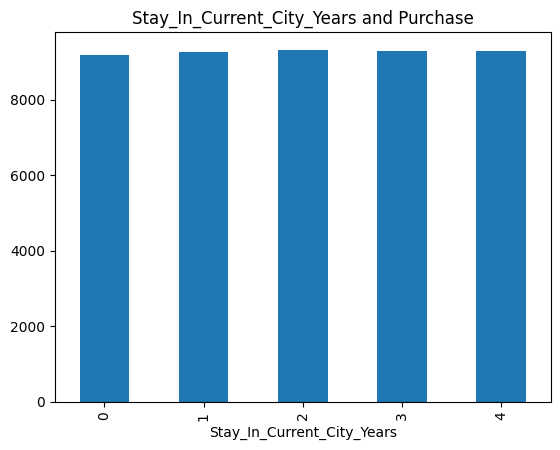

In [50]:
df_train.groupby('Stay_In_Current_City_Years').mean()['Purchase'].plot(kind='bar')
plt.title('Stay_In_Current_City_Years and Purchase')
plt.show()

<ipython-input-51-8225228167ae>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_train.groupby('Occupation').mean()['Purchase'].plot(kind='bar')


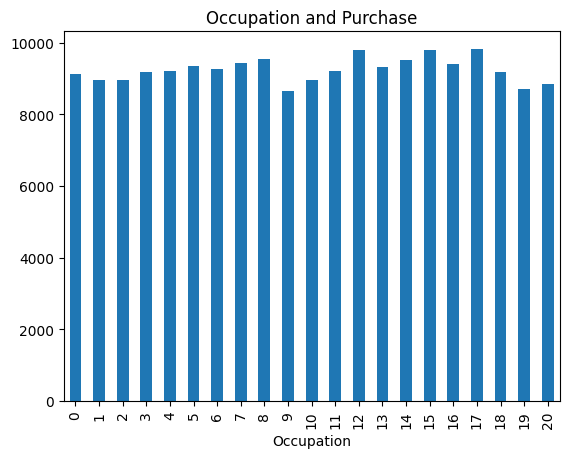

In [51]:
df_train.groupby('Occupation').mean()['Purchase'].plot(kind='bar')
plt.title('Occupation and Purchase')
plt.show()

<ipython-input-52-b132c5f5cacf>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_train.groupby('Product_Category_1').mean()['Purchase'].plot(kind='bar')


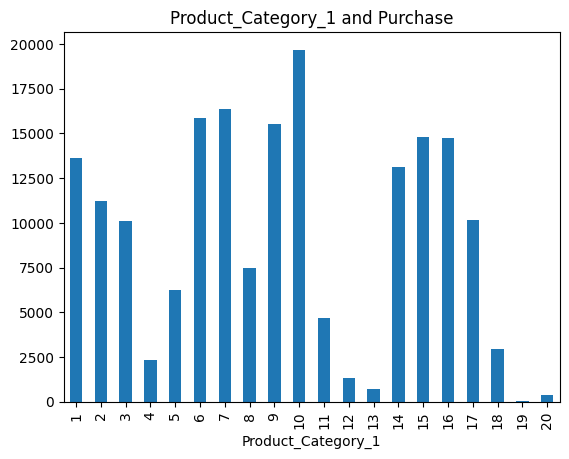

In [52]:
df_train.groupby('Product_Category_1').mean()['Purchase'].plot(kind='bar')
plt.title('Product_Category_1 and Purchase')
plt.show()

<ipython-input-53-4d7af8d2d44e>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_train.groupby('Product_Category_2').mean()['Purchase'].plot(kind='bar')


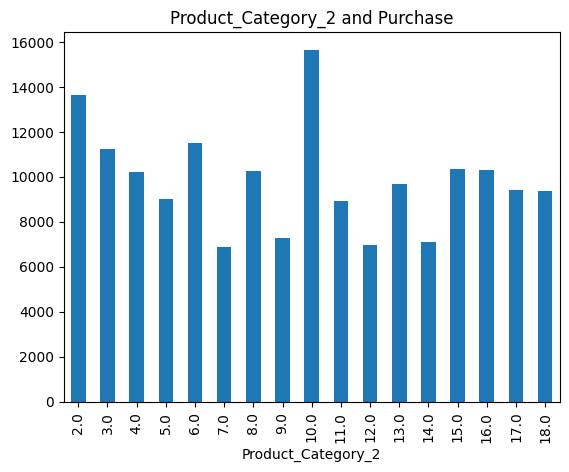

In [53]:
df_train.groupby('Product_Category_2').mean()['Purchase'].plot(kind='bar')
plt.title('Product_Category_2 and Purchase')
plt.show()

<ipython-input-54-568debe57eb4>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_train.groupby('Product_Category_3').mean()['Purchase'].plot(kind='bar')


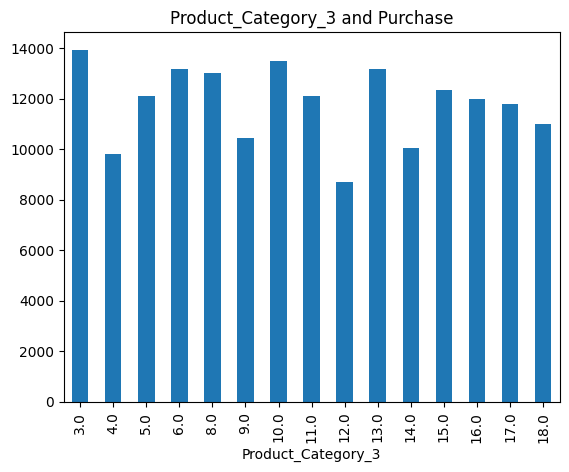

In [54]:
df_train.groupby('Product_Category_3').mean()['Purchase'].plot(kind='bar')
plt.title('Product_Category_3 and Purchase')
plt.show()

<Axes: xlabel='Gender', ylabel='Purchase'>

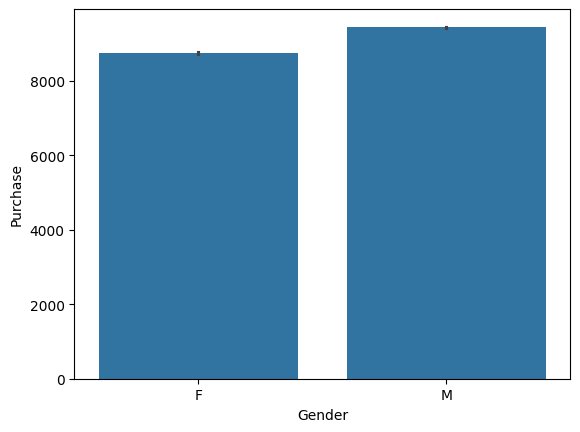

In [55]:
sns.barplot(x=df_train['Gender'],y=df_train['Purchase'])

Male customers purchases more than female

<Axes: xlabel='City_Category', ylabel='Purchase'>

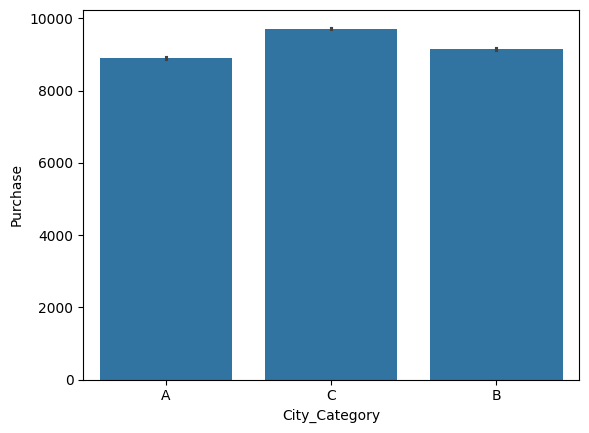

In [56]:
sns.barplot(x=df_train['City_Category'],y=df_train['Purchase'])

C has made the most purchases

<Axes: xlabel='Marital_Status', ylabel='Purchase'>

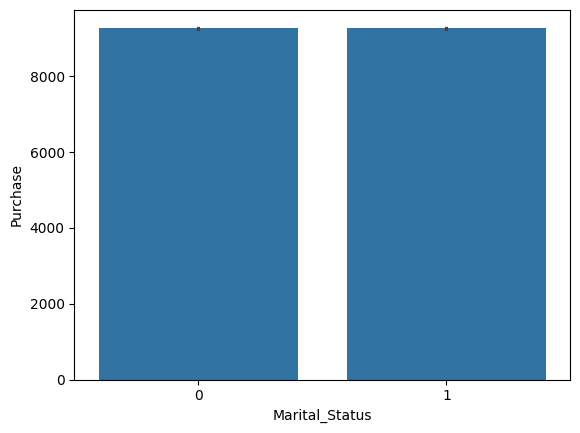

In [57]:
sns.barplot(x=df_train['Marital_Status'],y=df_train['Purchase'])

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='Purchase'>

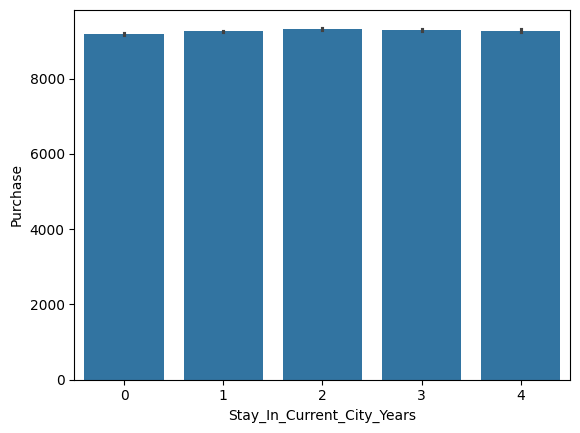

In [58]:
sns.barplot(x=df_train['Stay_In_Current_City_Years'],y=df_train['Purchase'])

<Axes: xlabel='Occupation', ylabel='Purchase'>

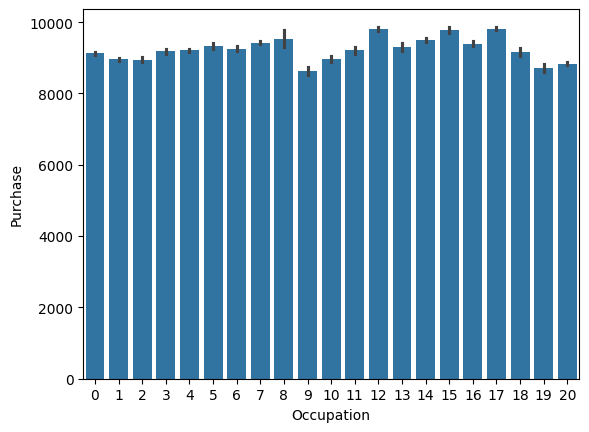

In [59]:
sns.barplot(x=df_train['Occupation'],y=df_train['Purchase'])

8,12,15 and 17 have made more purchases

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

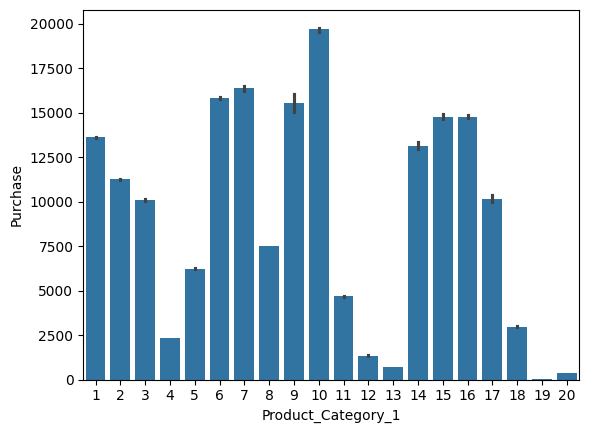

In [60]:
sns.barplot(x=df_train['Product_Category_1'],y=df_train['Purchase'])

10 has the most purchases during BlackFriday Sale

<Axes: xlabel='Product_Category_2', ylabel='Purchase'>

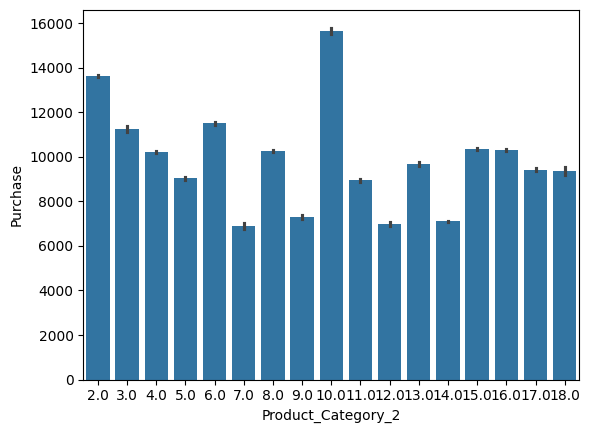

In [61]:
sns.barplot(x=df_train['Product_Category_2'],y=df_train['Purchase'])

<Axes: xlabel='Product_Category_3', ylabel='Purchase'>

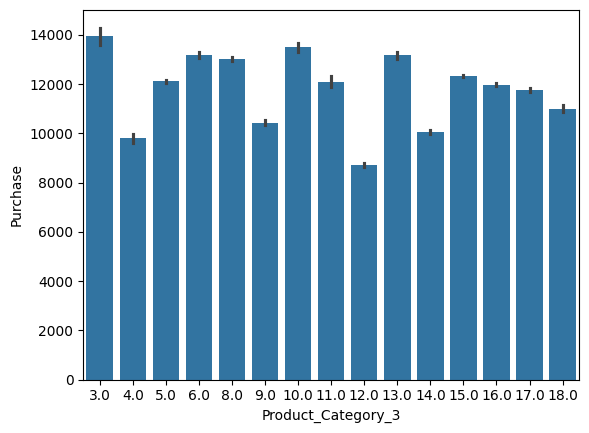

In [62]:
sns.barplot(x=df_train['Product_Category_3'],y=df_train['Purchase'])

<Axes: xlabel='Gender', ylabel='Purchase'>

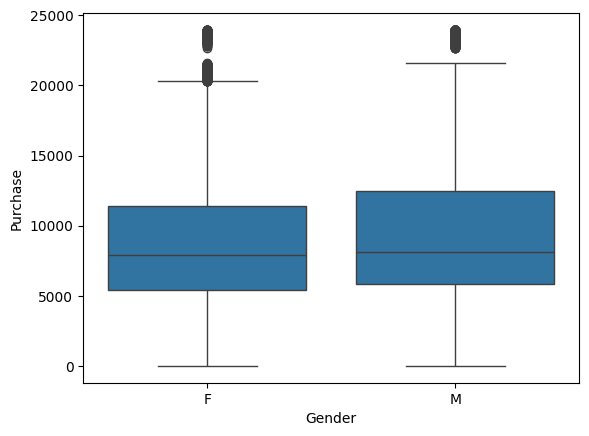

In [63]:
sns.boxplot(x=df_train['Gender'],y=df_train['Purchase'])

<Axes: xlabel='Marital_Status', ylabel='Purchase'>

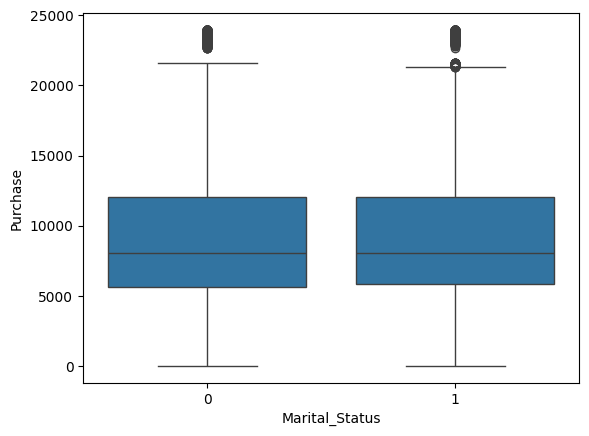

In [64]:
sns.boxplot(x=df_train['Marital_Status'],y=df_train['Purchase'])

<Axes: xlabel='City_Category', ylabel='Purchase'>

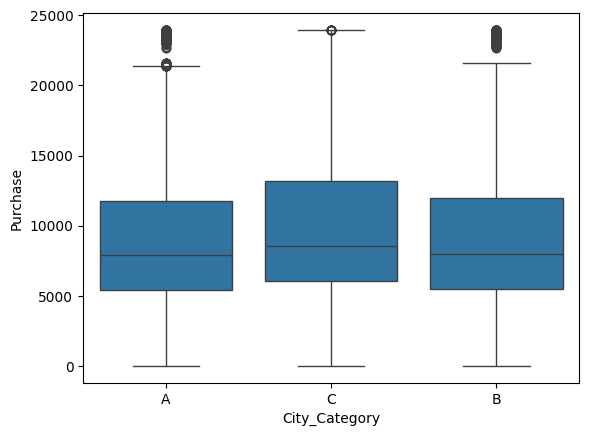

In [65]:
sns.boxplot(x=df_train['City_Category'],y=df_train['Purchase'])

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='Purchase'>

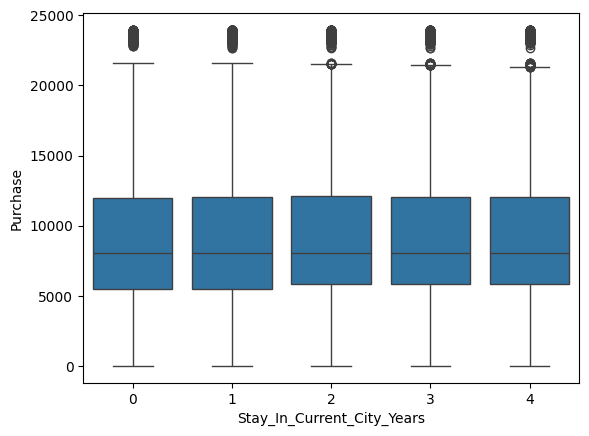

In [66]:
sns.boxplot(x=df_train['Stay_In_Current_City_Years'],y=df_train['Purchase'])

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

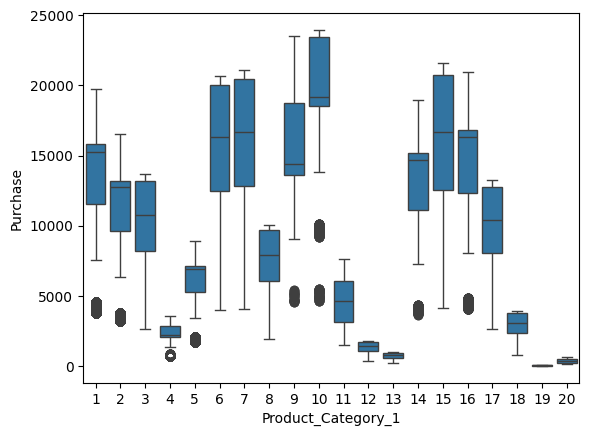

In [67]:
sns.boxplot(x=df_train['Product_Category_1'],y=df_train['Purchase'])

<Axes: xlabel='Product_Category_2', ylabel='Purchase'>

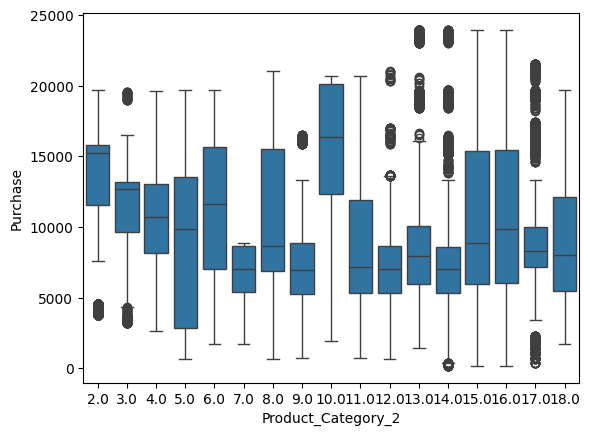

In [68]:
sns.boxplot(x=df_train['Product_Category_2'],y=df_train['Purchase'])

<Axes: xlabel='Product_Category_3', ylabel='Purchase'>

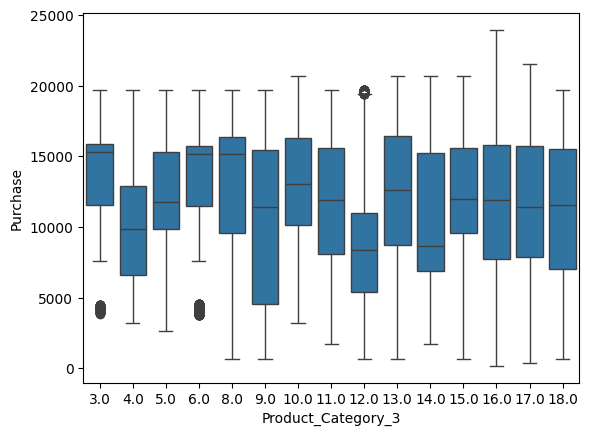

In [69]:
sns.boxplot(x=df_train['Product_Category_3'],y=df_train['Purchase'])

# **Feature Engineering**


## **Handling Missing Values**

## **Filling the missing data**
Using mode() function

In [70]:
df_train['Product_Category_2'].unique()

array([nan,  6., 14.,  2.,  8., 15., 16., 11.,  5.,  3.,  4., 12.,  9.,
       10., 17., 13.,  7., 18.])

In [71]:
df_test['Product_Category_2'].unique()

array([11.,  5., 14.,  9.,  3.,  4., 13.,  2., nan,  8., 15., 17., 12.,
       16.,  6., 10., 18.,  7.])

In [72]:
df_train['Product_Category_2'].mode()[0]

8.0

In [73]:
df_train['Product_Category_2']=df_train['Product_Category_2'].fillna(df_train['Product_Category_2'].mode()[0])
df_train.isnull().sum()

Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2                 0
Product_Category_3            383247
Purchase                           0
dtype: int64

In [74]:
df_train['Product_Category_3'].mode()[0]

16.0

In [75]:
df_train['Product_Category_3']=df_train['Product_Category_3'].fillna(df_train['Product_Category_3'].mode()[0])
df_train.isnull().sum()

Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

In [76]:
df_train['Product_Category_2']=df_train['Product_Category_2'].astype(int)
df_train.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,F,0-17,10,A,2,0,3,8,16.0,8370
1,P00248942,F,0-17,10,A,2,0,1,6,14.0,15200
2,P00087842,F,0-17,10,A,2,0,12,8,16.0,1422
3,P00085442,F,0-17,10,A,2,0,12,14,16.0,1057
4,P00285442,M,55+,16,C,4,0,8,8,16.0,7969


In [77]:
df_train['Product_Category_3']=df_train['Product_Category_3'].astype(int)
df_train.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,F,0-17,10,A,2,0,3,8,16,8370
1,P00248942,F,0-17,10,A,2,0,1,6,14,15200
2,P00087842,F,0-17,10,A,2,0,12,8,16,1422
3,P00085442,F,0-17,10,A,2,0,12,14,16,1057
4,P00285442,M,55+,16,C,4,0,8,8,16,7969


In [78]:
df_train=df_train.drop(['Product_Category_3'],axis=1)
df_train.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase
0,P00069042,F,0-17,10,A,2,0,3,8,8370
1,P00248942,F,0-17,10,A,2,0,1,6,15200
2,P00087842,F,0-17,10,A,2,0,12,8,1422
3,P00085442,F,0-17,10,A,2,0,12,14,1057
4,P00285442,M,55+,16,C,4,0,8,8,7969


### **Handling Categorical data**

#### Coverting categorical values into integer ('Gender coloumn')

In [79]:
df_train['Gender']=df_train['Gender'].map({'F':0,'M':1}) #categorical to integer

In [80]:
df_train.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase
0,P00069042,0,0-17,10,A,2,0,3,8,8370
1,P00248942,0,0-17,10,A,2,0,1,6,15200
2,P00087842,0,0-17,10,A,2,0,12,8,1422
3,P00085442,0,0-17,10,A,2,0,12,14,1057
4,P00285442,1,55+,16,C,4,0,8,8,7969


In [81]:
pd.get_dummies(df_train['Age'],drop_first=False)

,0-17,18-25,26-35,36-45,46-50,51-55,55+
0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0
4,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...
550063,0,0,0,0,0,1,0
550064,0,0,1,0,0,0,0
550065,0,0,1,0,0,0,0
550066,0,0,0,0,0,0,1


In [82]:
df_train['Age']=df_train['Age'].map({'0-17':1,'18-25':2,'26-35':3,'36-45':4,'46-50':5,'51-55':6,'55+':7}) #categorical to integer
df_train.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase
0,P00069042,0,1,10,A,2,0,3,8,8370
1,P00248942,0,1,10,A,2,0,1,6,15200
2,P00087842,0,1,10,A,2,0,12,8,1422
3,P00085442,0,1,10,A,2,0,12,14,1057
4,P00285442,1,7,16,C,4,0,8,8,7969


In [83]:
df_city=pd.get_dummies(df_train['City_Category'],drop_first=False)

In [84]:
df_train=pd.concat([df_train,df_city],axis=1)

In [85]:
df_train.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase,A,B,C
0,P00069042,0,1,10,A,2,0,3,8,8370,1,0,0
1,P00248942,0,1,10,A,2,0,1,6,15200,1,0,0
2,P00087842,0,1,10,A,2,0,12,8,1422,1,0,0
3,P00085442,0,1,10,A,2,0,12,14,1057,1,0,0
4,P00285442,1,7,16,C,4,0,8,8,7969,0,0,1


In [86]:
df_train.drop('City_Category',axis=1,inplace=True)

In [87]:
df_train.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase,A,B,C
0,P00069042,0,1,10,2,0,3,8,8370,1,0,0
1,P00248942,0,1,10,2,0,1,6,15200,1,0,0
2,P00087842,0,1,10,2,0,12,8,1422,1,0,0
3,P00085442,0,1,10,2,0,12,14,1057,1,0,0
4,P00285442,1,7,16,4,0,8,8,7969,0,0,1


In [88]:
df_train=df_train.drop(['Product_ID'],axis=1)
df_train.head()

,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase,A,B,C
0,0,1,10,2,0,3,8,8370,1,0,0
1,0,1,10,2,0,1,6,15200,1,0,0
2,0,1,10,2,0,12,8,1422,1,0,0
3,0,1,10,2,0,12,14,1057,1,0,0
4,1,7,16,4,0,8,8,7969,0,0,1


## **Train and Test Split**

In [89]:
x=df_train.drop(['Purchase'],axis=1)
y=df_train['Purchase']

In [90]:
from sklearn.model_selection import train_test_split
x_train,y_train,x_test,y_test=train_test_split(x,y,test_size=0.1,random_state=0)

In [91]:
x_train.shape

(495061, 10)

In [92]:
y_train.shape

(55007, 10)

In [93]:
x_test.shape

(495061,)

## **MinMaxScaling**

In [94]:
from sklearn.preprocessing import MinMaxScaler

In [95]:
scaler=MinMaxScaler()
x_test_scaled=scaler.fit_transform(x_test.values.reshape(-1, 1))

In [96]:
scaler=MinMaxScaler()
scaler.fit(x_train)
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test.values.reshape(-1, 1))

In [97]:
x_train_scaled = pd.DataFrame(x_train_scaled)
columns=x_train_scaled.columns

In [98]:
x_test_scaled = pd.DataFrame(x_test_scaled)
columns=x_test_scaled.columns

In [99]:

np.round(pd.DataFrame(x_train).describe(),1)
np.round(pd.DataFrame(x_train_scaled).describe(),1)

,0,1,2,3,4,5,6,7,8,9
count,495061.0,495061.0,495061.0,495061.0,495061.0,495061.0,495061.0,495061.0,495061.0,495061.0
mean,0.8,0.4,0.4,0.5,0.4,0.2,0.5,0.3,0.4,0.3
std,0.4,0.2,0.3,0.3,0.5,0.2,0.3,0.4,0.5,0.5
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,0.3,0.1,0.2,0.0,0.0,0.4,0.0,0.0,0.0
50%,1.0,0.3,0.4,0.5,0.0,0.2,0.4,0.0,0.0,0.0
75%,1.0,0.5,0.7,0.8,1.0,0.4,0.8,1.0,1.0,1.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


<ipython-input-100-57036ca510a3>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Gender'],ax=ax1,hist=False)
<ipython-input-100-57036ca510a3>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
<ipython-input-100-57036ca510a3>:7: 

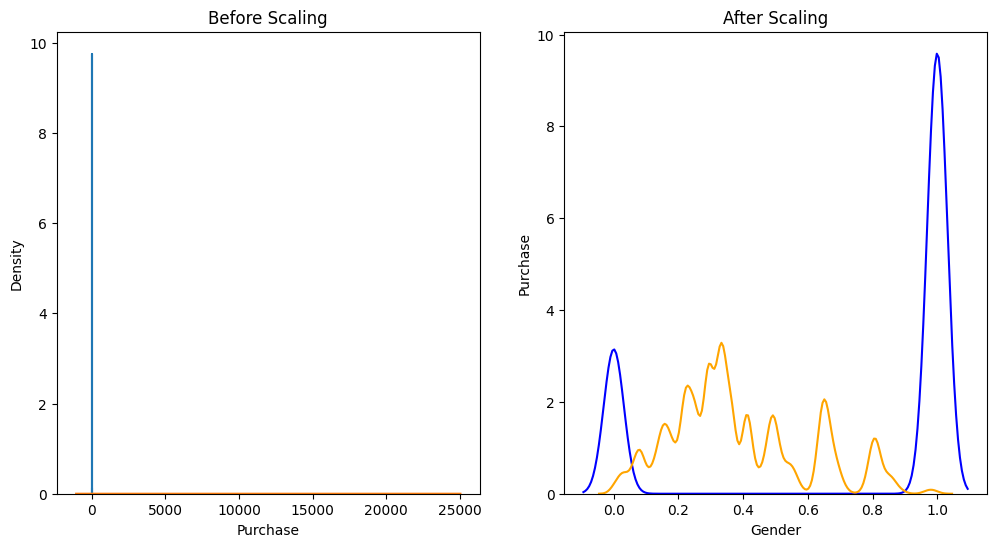

In [100]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
## before scaling
sns.distplot(df_train['Gender'],ax=ax1,hist=False)
sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
ax1.set_title('Before Scaling')
## after scaling
sns.distplot(x_train_scaled[0],ax=ax2,color='blue',hist=False)
sns.distplot(x_test_scaled,ax=ax2,color='orange',hist=False)
plt.xlabel('Gender')
plt.ylabel('Purchase')
ax2.set_title('After Scaling')
plt.show()

<ipython-input-101-3838e4b48fac>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Age'],ax=ax1,hist=False)
<ipython-input-101-3838e4b48fac>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
<ipython-input-101-3838e4b48fac>:7: Use

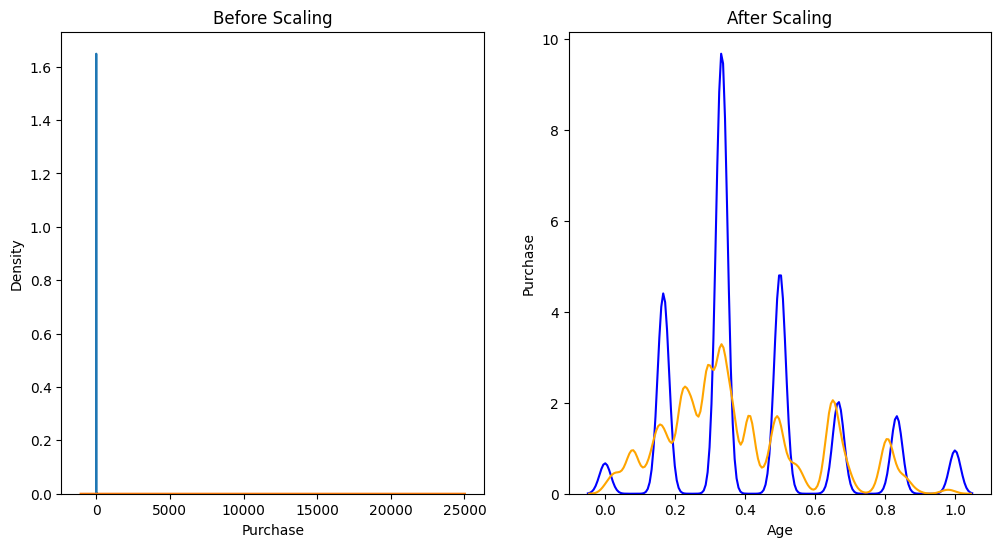

In [101]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
## before scaling
sns.distplot(df_train['Age'],ax=ax1,hist=False)
sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
ax1.set_title('Before Scaling')
## after scaling
sns.distplot(x_train_scaled[1],ax=ax2,color='blue',hist=False)
sns.distplot(x_test_scaled,ax=ax2,color='orange',hist=False)
plt.xlabel('Age')
plt.ylabel('Purchase')
ax2.set_title('After Scaling')
plt.show()

<ipython-input-102-2cd1f2989540>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Occupation'],ax=ax1,hist=False)
<ipython-input-102-2cd1f2989540>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
<ipython-input-102-2cd1f2989540>

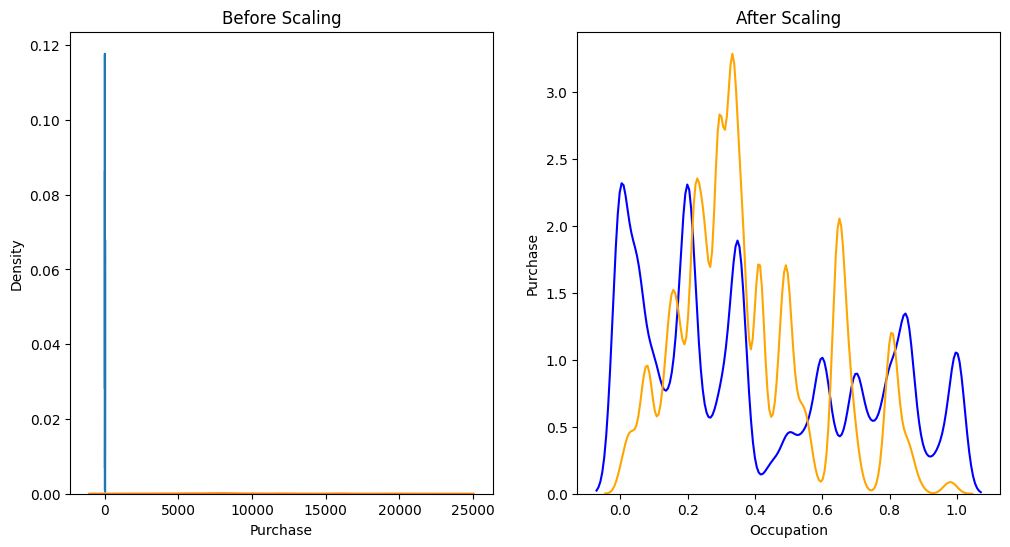

In [102]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
## before scaling
sns.distplot(df_train['Occupation'],ax=ax1,hist=False)
sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
ax1.set_title('Before Scaling')
## after scaling
sns.distplot(x_train_scaled[2],ax=ax2,color='blue',hist=False)
sns.distplot(x_test_scaled,ax=ax2,color='orange',hist=False)
plt.xlabel('Occupation')
plt.ylabel('Purchase')
ax2.set_title('After Scaling')
plt.show()

<ipython-input-103-986f2bccad9b>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Stay_In_Current_City_Years'],ax=ax1,hist=False)
<ipython-input-103-986f2bccad9b>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
<ipython-input-1

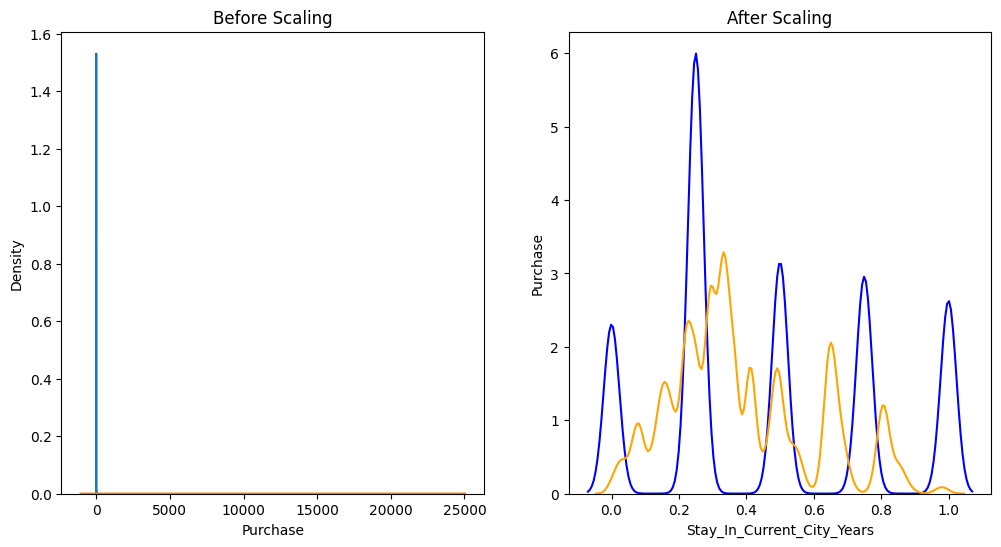

In [103]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
## before scaling
sns.distplot(df_train['Stay_In_Current_City_Years'],ax=ax1,hist=False)
sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
ax1.set_title('Before Scaling')
## after scaling
sns.distplot(x_train_scaled[3],ax=ax2,color='blue',hist=False)
sns.distplot(x_test_scaled,ax=ax2,color='orange',hist=False)
plt.xlabel('Stay_In_Current_City_Years')
plt.ylabel('Purchase')
ax2.set_title('After Scaling')
plt.show()

<ipython-input-104-2762eb184b4e>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Marital_Status'],ax=ax1,hist=False)
<ipython-input-104-2762eb184b4e>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
<ipython-input-104-2762eb184

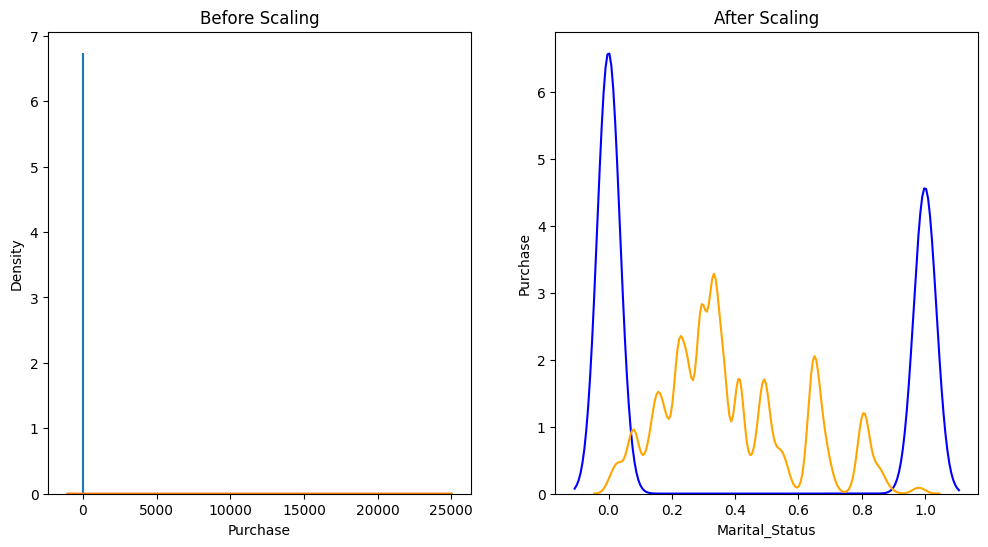

In [104]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
## before scaling
sns.distplot(df_train['Marital_Status'],ax=ax1,hist=False)
sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
ax1.set_title('Before Scaling')
## after scaling
sns.distplot(x_train_scaled[4],ax=ax2,color='blue',hist=False)
sns.distplot(x_test_scaled,ax=ax2,color='orange',hist=False)
plt.xlabel('Marital_Status')
plt.ylabel('Purchase')
ax2.set_title('After Scaling')
plt.show()

<ipython-input-105-98d05f5c1e1a>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Product_Category_1'],ax=ax1,hist=False)
<ipython-input-105-98d05f5c1e1a>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
<ipython-input-105-98d05

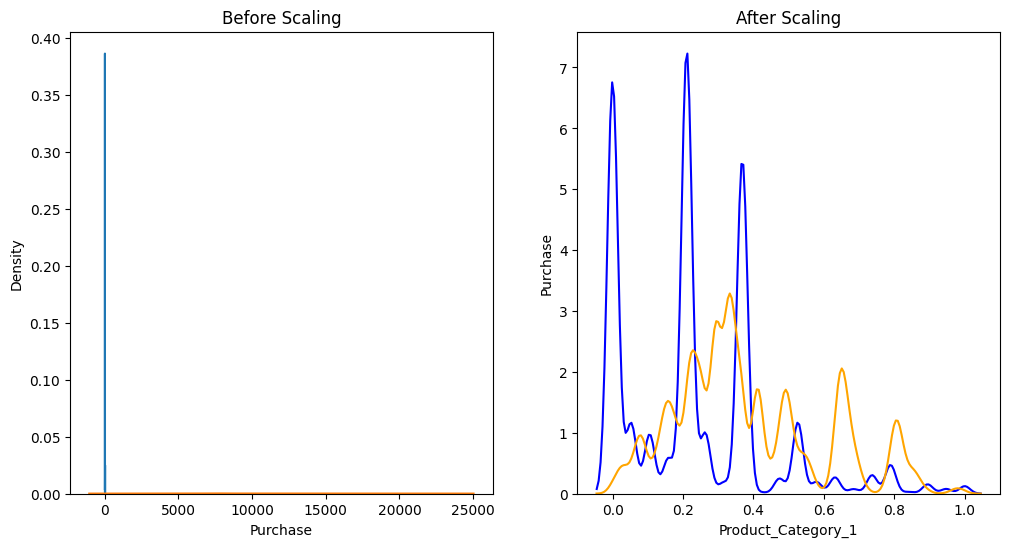

In [105]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
## before scaling
sns.distplot(df_train['Product_Category_1'],ax=ax1,hist=False)
sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
ax1.set_title('Before Scaling')
## after scaling
sns.distplot(x_train_scaled[5],ax=ax2,color='blue',hist=False)
sns.distplot(x_test_scaled,ax=ax2,color='orange',hist=False)
plt.xlabel('Product_Category_1')
plt.ylabel('Purchase')
ax2.set_title('After Scaling')
plt.show()

<ipython-input-106-40518e67649a>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Product_Category_2'],ax=ax1,hist=False)
<ipython-input-106-40518e67649a>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
<ipython-input-106-40518

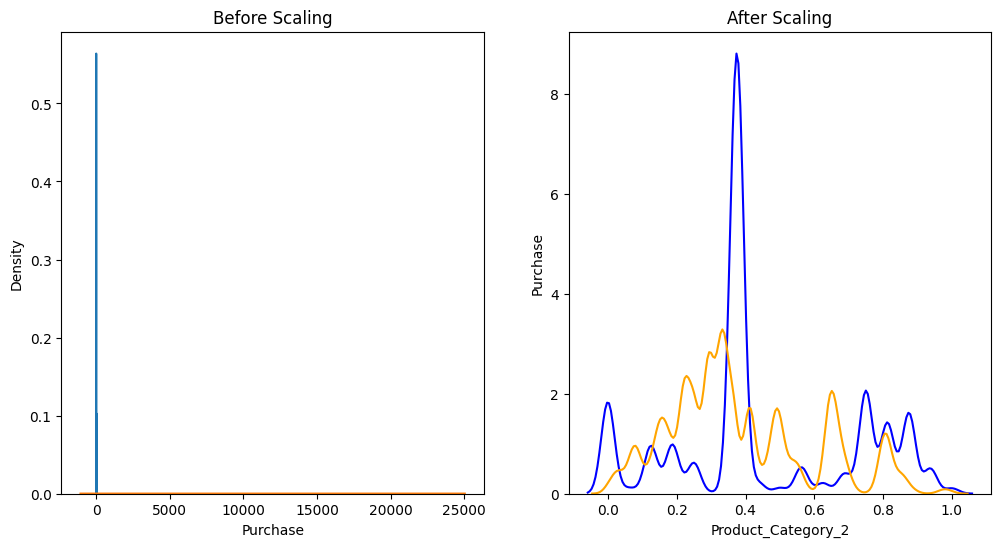

In [106]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
## before scaling
sns.distplot(df_train['Product_Category_2'],ax=ax1,hist=False)
sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
ax1.set_title('Before Scaling')
## after scaling
sns.distplot(x_train_scaled[6],ax=ax2,color='blue',hist=False)
sns.distplot(x_test_scaled,ax=ax2,color='orange',hist=False)
plt.xlabel('Product_Category_2')
plt.ylabel('Purchase')
ax2.set_title('After Scaling')
plt.show()

<ipython-input-107-c2e692718643>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['A'],ax=ax1,hist=False)
<ipython-input-107-c2e692718643>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
<ipython-input-107-c2e692718643>:7: UserW

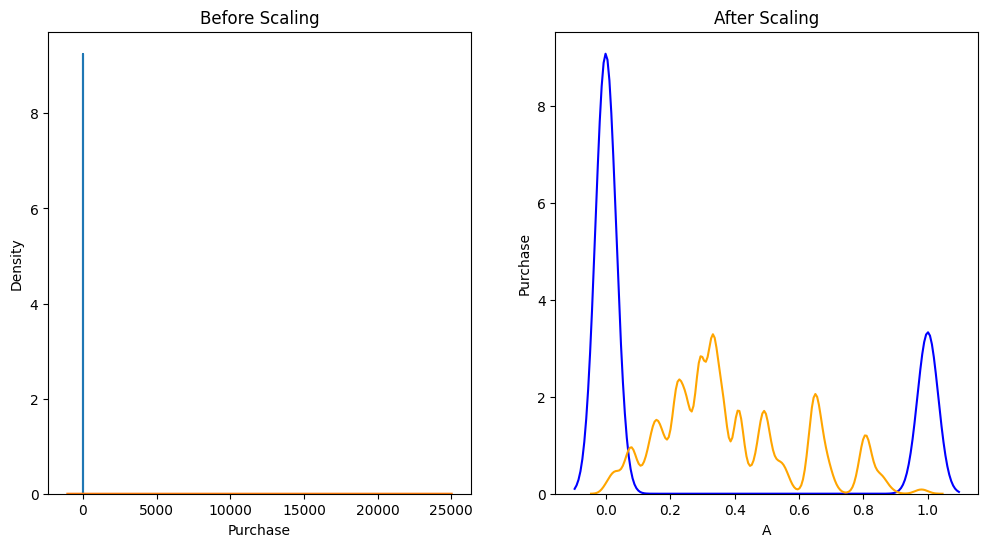

In [107]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
## before scaling
sns.distplot(df_train['A'],ax=ax1,hist=False)
sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
ax1.set_title('Before Scaling')
## after scaling
sns.distplot(x_train_scaled[7],ax=ax2,color='blue',hist=False)
sns.distplot(x_test_scaled,ax=ax2,color='orange',hist=False)
plt.xlabel('A')
plt.ylabel('Purchase')
ax2.set_title('After Scaling')
plt.show()

<ipython-input-108-0089c5a27768>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['B'],ax=ax1,hist=False)
<ipython-input-108-0089c5a27768>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
<ipython-input-108-0089c5a27768>:7: UserW

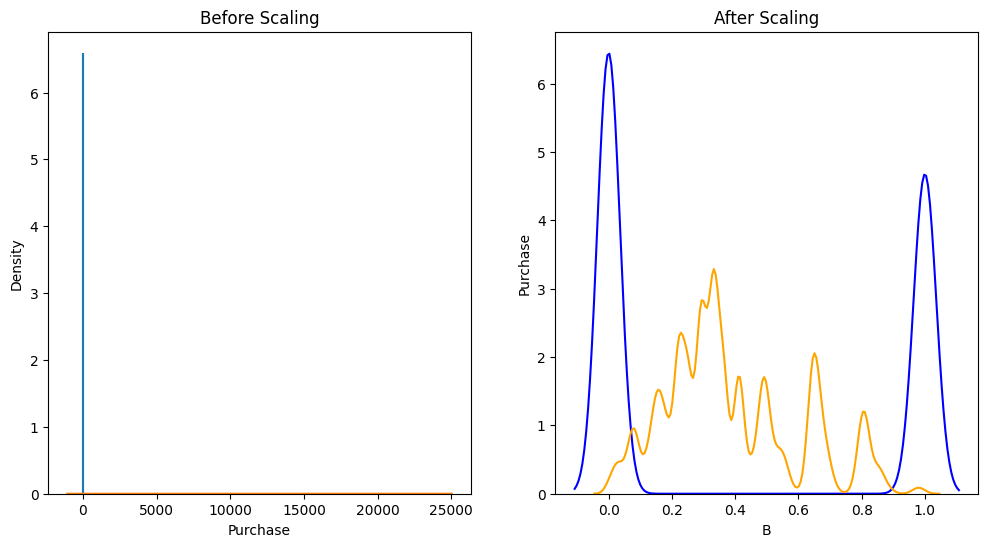

In [108]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
## before scaling
sns.distplot(df_train['B'],ax=ax1,hist=False)
sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
ax1.set_title('Before Scaling')
## after scaling
sns.distplot(x_train_scaled[8],ax=ax2,color='blue',hist=False)
sns.distplot(x_test_scaled,ax=ax2,color='orange',hist=False)
plt.xlabel('B')
plt.ylabel('Purchase')
ax2.set_title('After Scaling')
plt.show()

<ipython-input-109-b6deab42c070>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['C'],ax=ax1,hist=False)
<ipython-input-109-b6deab42c070>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
<ipython-input-109-b6deab42c070>:7: UserW

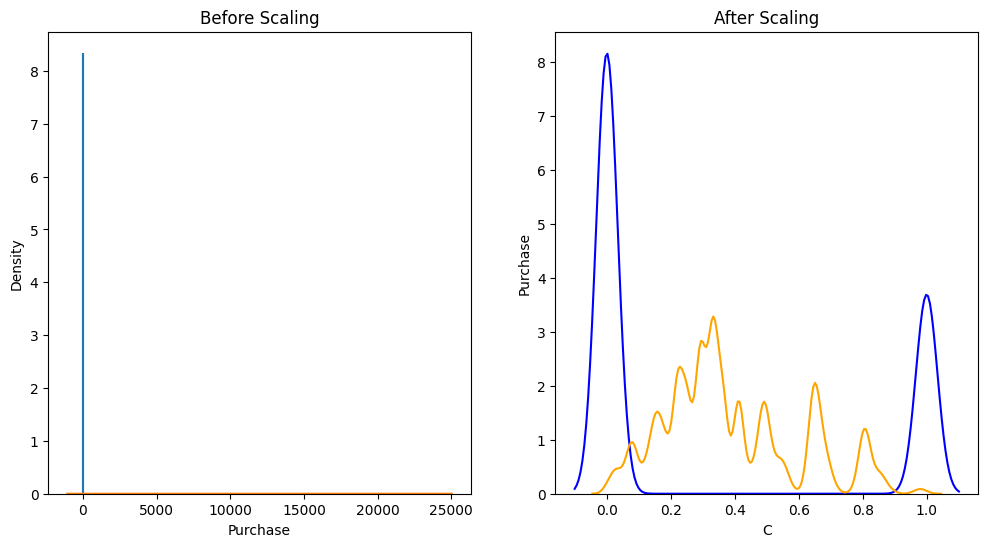

In [109]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
## before scaling
sns.distplot(df_train['C'],ax=ax1,hist=False)
sns.distplot(df_train['Purchase'],ax=ax1,hist=False)
ax1.set_title('Before Scaling')
## after scaling
sns.distplot(x_train_scaled[9],ax=ax2,color='blue',hist=False)
sns.distplot(x_test_scaled,ax=ax2,color='orange',hist=False)
plt.xlabel('C')
plt.ylabel('Purchase')
ax2.set_title('After Scaling')
plt.show()

## **Using QQplot  and pandas skew () and kdeplot() to detect skewness**

In [110]:
import scipy.stats as stats

In [111]:
df=pd.DataFrame(x_train['Age'])
print(df.skew())

Age    0.807717
dtype: float64


In [112]:
df=pd.DataFrame(x_train['Occupation'])
print(df.skew())

Occupation    0.399824
dtype: float64


In [113]:
df=pd.DataFrame(x_train['Gender'])
print(df.skew())

Gender   -1.173809
dtype: float64


In [114]:
df=pd.DataFrame(x_train['Stay_In_Current_City_Years'])
print(df.skew())

Stay_In_Current_City_Years    0.315906
dtype: float64


In [115]:
df=pd.DataFrame(x_train['Marital_Status'])
print(df.skew())

Marital_Status    0.367957
dtype: float64


In [116]:
df=pd.DataFrame(x_train['Product_Category_1'])
print(df.skew())

Product_Category_1    1.02549
dtype: float64


In [117]:
df=pd.DataFrame(x_train['Product_Category_2'])
print(df.skew())

Product_Category_2    0.197532
dtype: float64


In [118]:
df=pd.DataFrame(df_train['Purchase'])
print(df.skew())

Purchase    0.60014
dtype: float64


In [119]:
df=pd.DataFrame(x_train['A'])
print(df.skew())

A    1.045341
dtype: float64


In [120]:
df=pd.DataFrame(x_train['B'])
print(df.skew())

B    0.322956
dtype: float64


In [121]:
df=pd.DataFrame(x_train['C'])
print(df.skew())

C    0.815011
dtype: float64


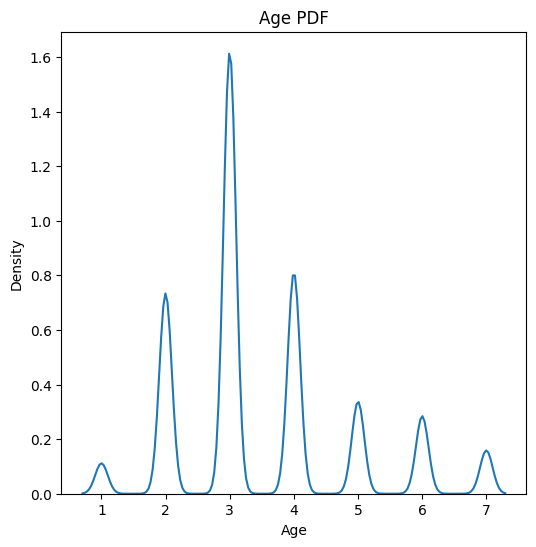

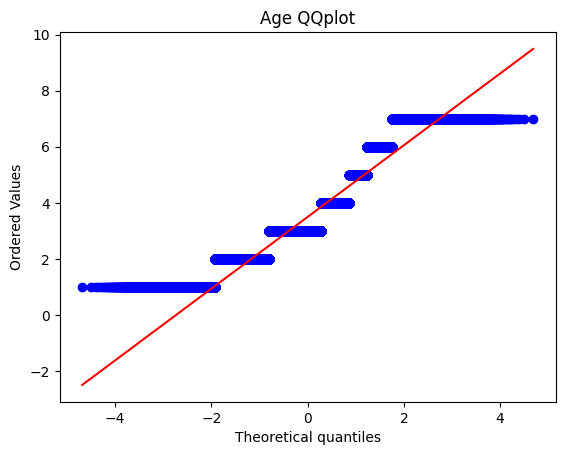

In [122]:
plt.figure(figsize=(6,6))
sns.kdeplot(x_train['Age'])
plt.title('Age PDF')
plt.show()

stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('Age QQplot')
plt.show()

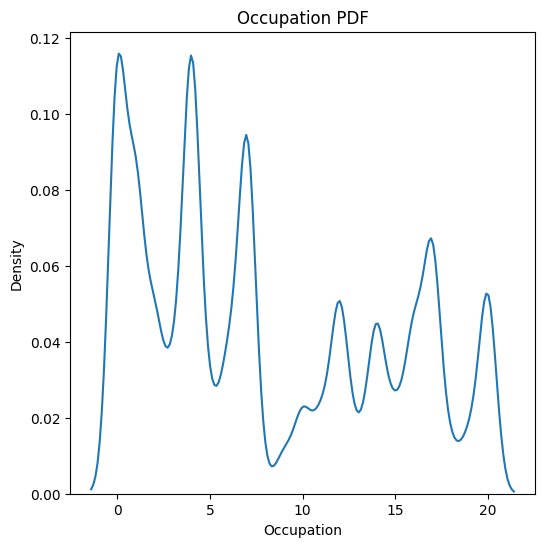

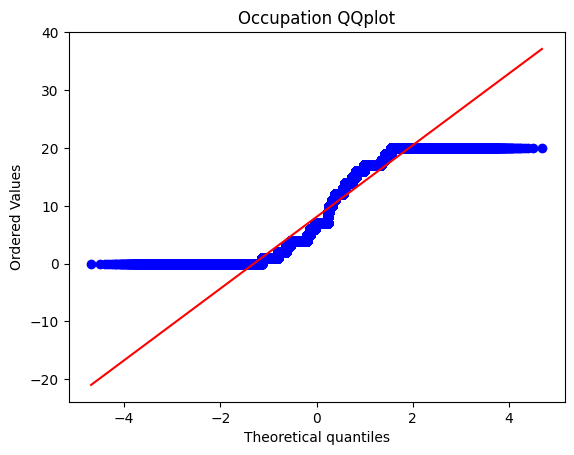

In [123]:
plt.figure(figsize=(6,6))
sns.kdeplot(x_train['Occupation'])
plt.title('Occupation PDF')
plt.show()

stats.probplot(x_train['Occupation'],dist='norm',plot=plt)
plt.title('Occupation QQplot')
plt.show()

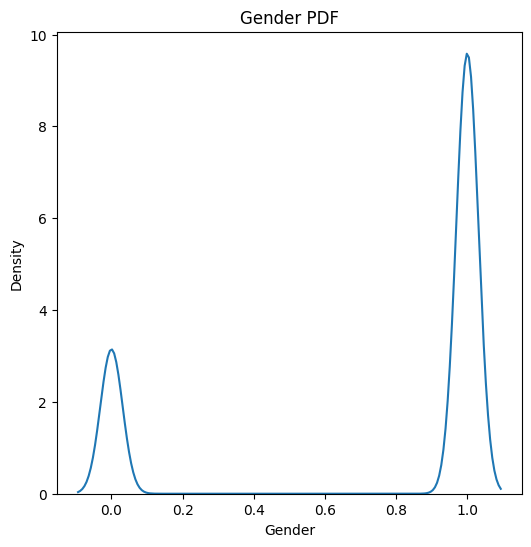

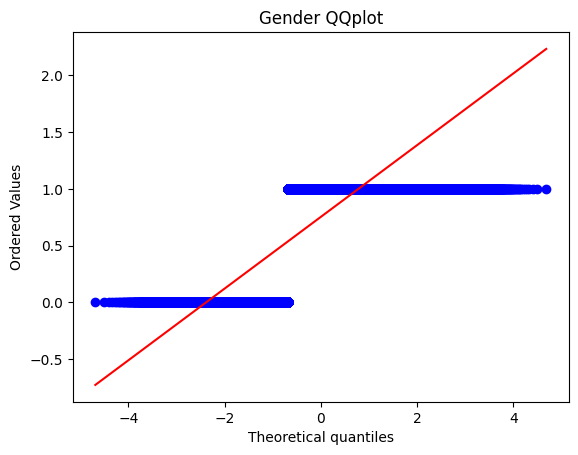

In [124]:
plt.figure(figsize=(6,6))
sns.kdeplot(x_train['Gender'])
plt.title('Gender PDF')
plt.show()

stats.probplot(x_train['Gender'],dist='norm',plot=plt)
plt.title('Gender QQplot')
plt.show()

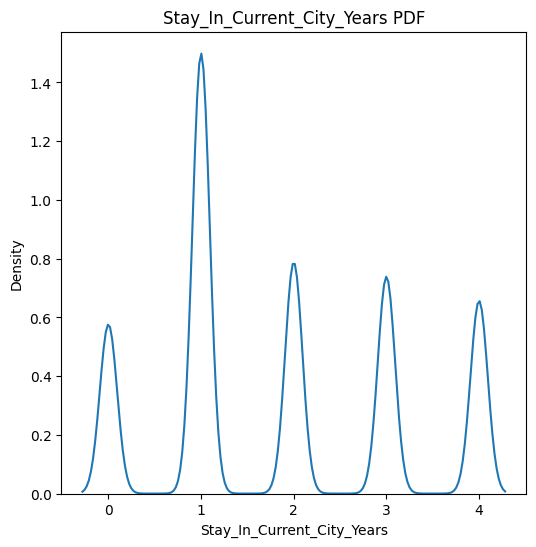

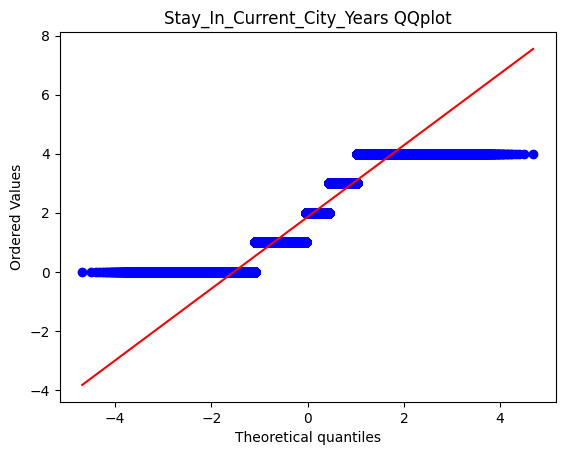

In [125]:
plt.figure(figsize=(6,6))
sns.kdeplot(x_train['Stay_In_Current_City_Years'])
plt.title('Stay_In_Current_City_Years PDF')
plt.show()

stats.probplot(x_train['Stay_In_Current_City_Years'],dist='norm',plot=plt)
plt.title('Stay_In_Current_City_Years QQplot')
plt.show()

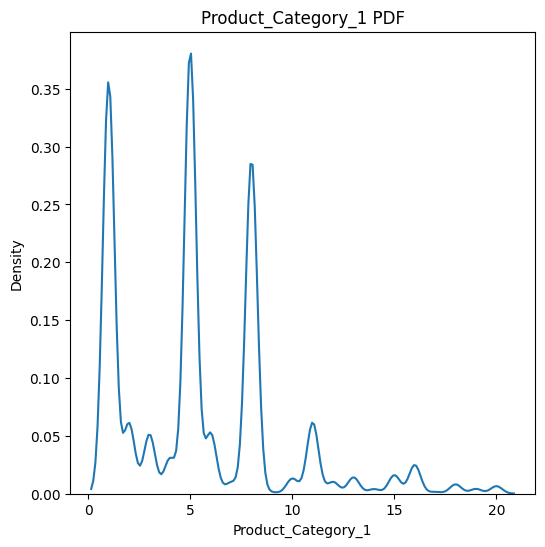

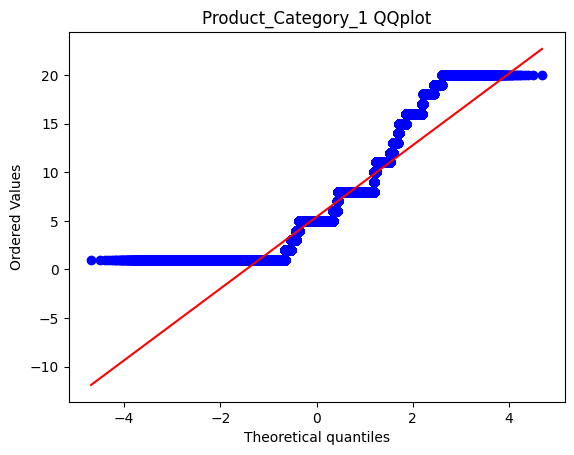

In [126]:
plt.figure(figsize=(6,6))
sns.kdeplot(x_train['Product_Category_1'])
plt.title('Product_Category_1 PDF')
plt.show()

stats.probplot(x_train['Product_Category_1'],dist='norm',plot=plt)
plt.title('Product_Category_1 QQplot')
plt.show()

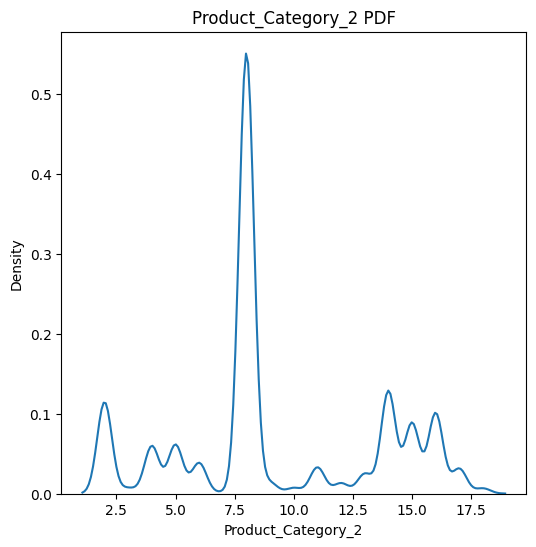

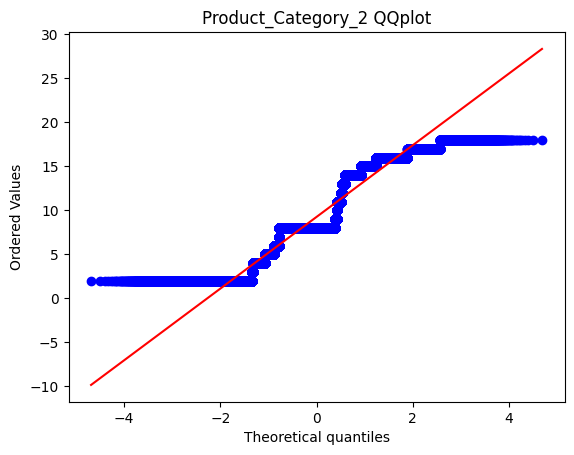

In [127]:
plt.figure(figsize=(6,6))
sns.kdeplot(x_train['Product_Category_2'])
plt.title('Product_Category_2 PDF')
plt.show()

stats.probplot(x_train['Product_Category_2'],dist='norm',plot=plt)
plt.title('Product_Category_2 QQplot')
plt.show()

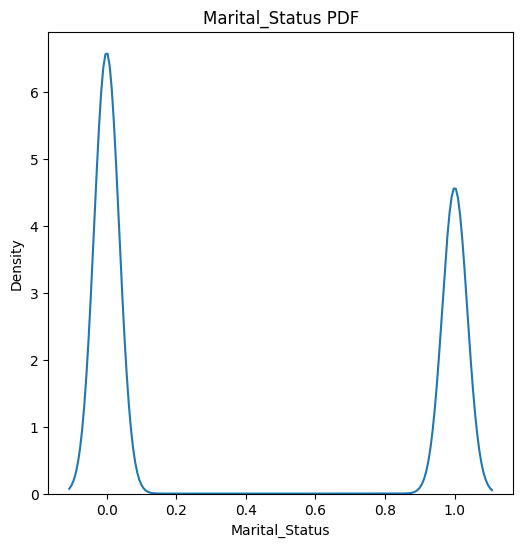

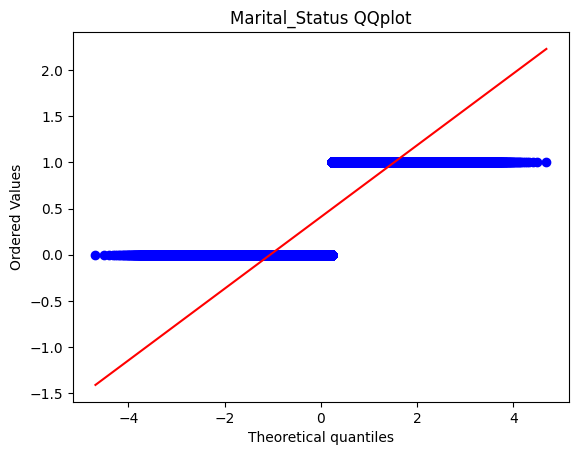

In [128]:
plt.figure(figsize=(6,6))
sns.kdeplot(x_train['Marital_Status'])
plt.title('Marital_Status PDF')
plt.show()

stats.probplot(x_train['Marital_Status'],dist='norm',plot=plt)
plt.title('Marital_Status QQplot')
plt.show()

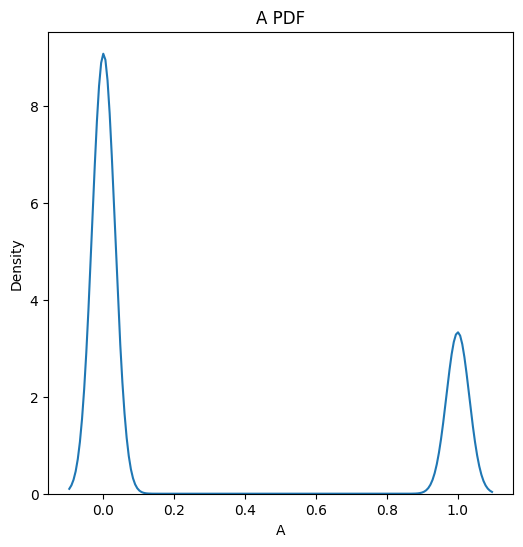

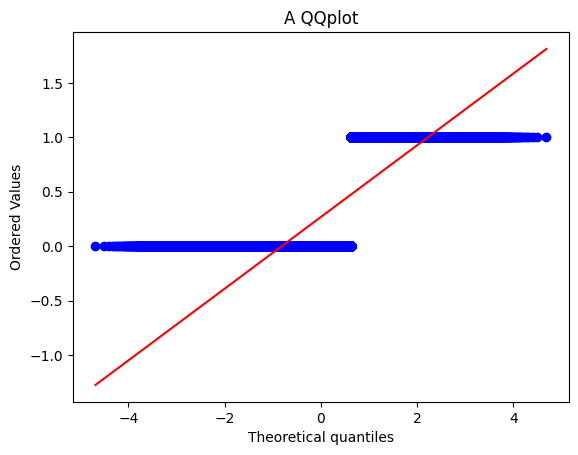

In [129]:
plt.figure(figsize=(6,6))
sns.kdeplot(x_train['A'])
plt.title('A PDF')
plt.show()

stats.probplot(x_train['A'],dist='norm',plot=plt)
plt.title('A QQplot')
plt.show()

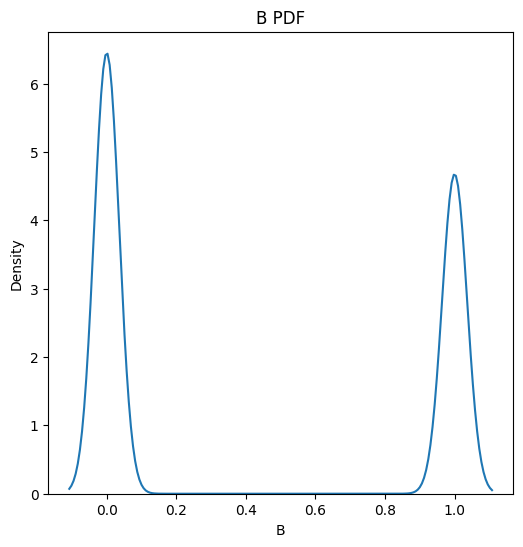

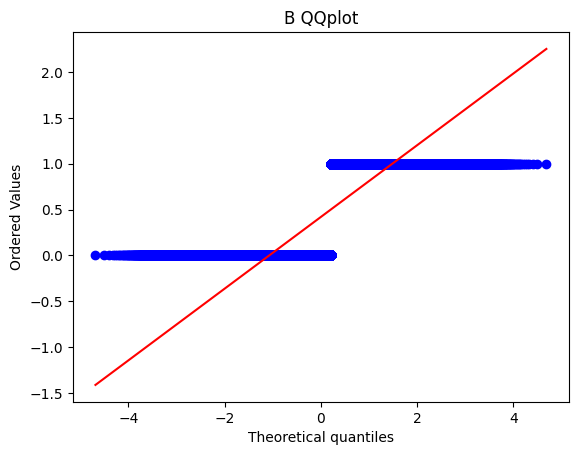

In [130]:
plt.figure(figsize=(6,6))
sns.kdeplot(x_train['B'])
plt.title('B PDF')
plt.show()

stats.probplot(x_train['B'],dist='norm',plot=plt)
plt.title('B QQplot')
plt.show()

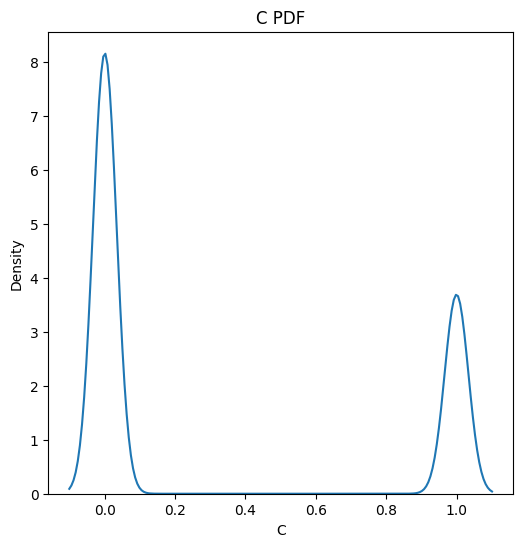

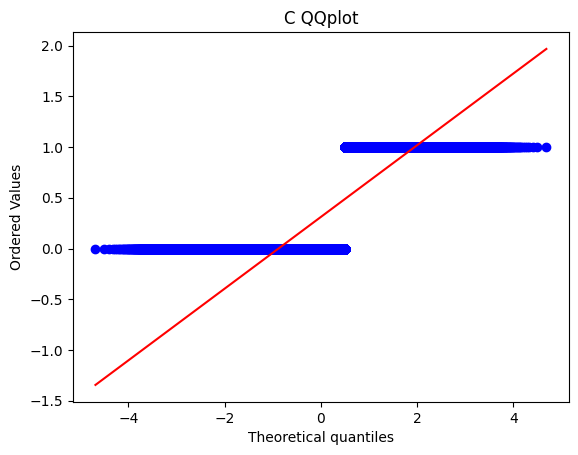

In [131]:
plt.figure(figsize=(6,6))
sns.kdeplot(x_train['C'])
plt.title('C PDF')
plt.show()

stats.probplot(x_train['C'],dist='norm',plot=plt)
plt.title('C QQplot')
plt.show()

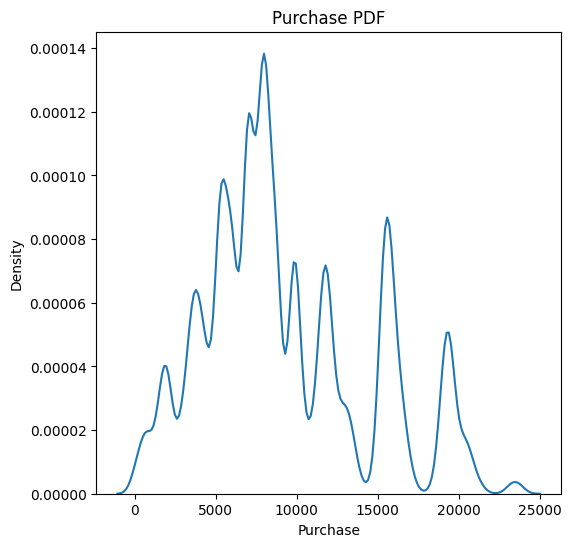

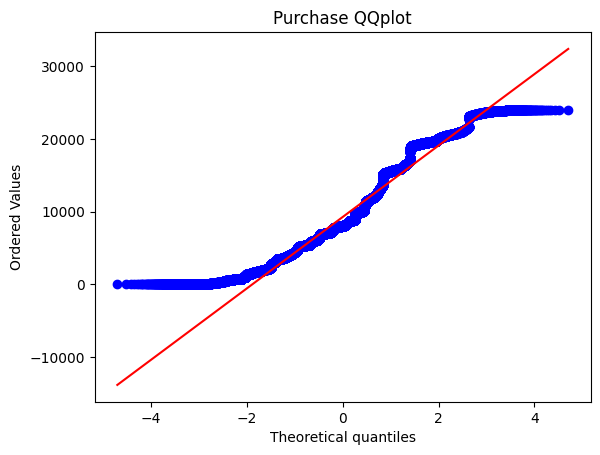

In [132]:
plt.figure(figsize=(6,6))
sns.kdeplot(df_train['Purchase'])
plt.title('Purchase PDF')
plt.show()

stats.probplot(df_train['Purchase'],dist='norm',plot=plt)
plt.title('Purchase QQplot')
plt.show()

## **Removing skewness**

In [133]:
data=np.sin(x_train['Product_Category_1'])

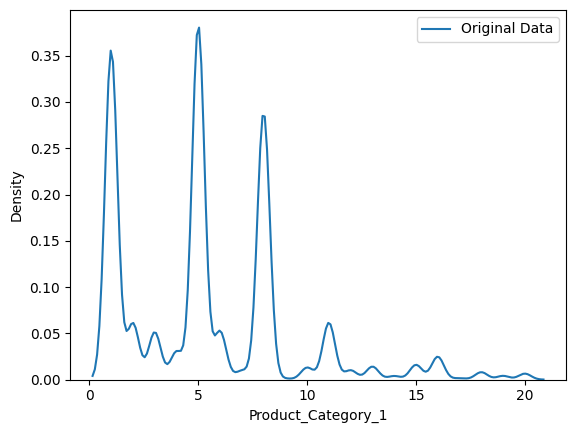

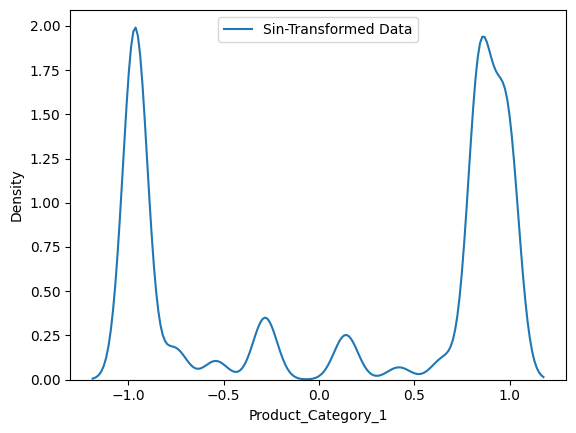

In [134]:
sns.kdeplot(x_train['Product_Category_1'], label='Original Data')
plt.legend()
plt.show()
sns.kdeplot(data, label='Sin-Transformed Data')
plt.legend()
plt.show()

In [135]:
df=pd.DataFrame(data)
print(df.skew())

Product_Category_1   -0.325904
dtype: float64


we can observe that skewness has removed from the data,data is now fairly symmetrical


-0.5 to 0.5 = fairly symmetrical

In [136]:
data1=np.log1p(x_train['Age'])

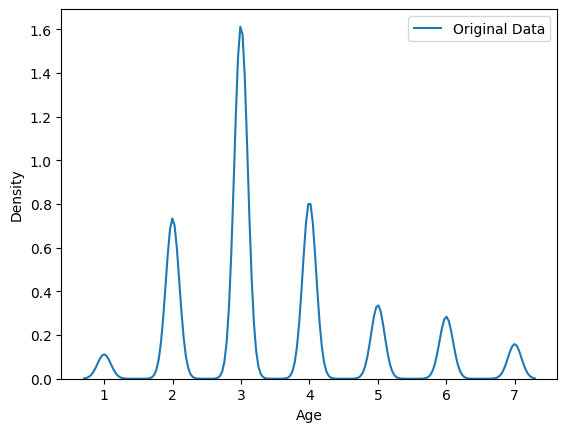

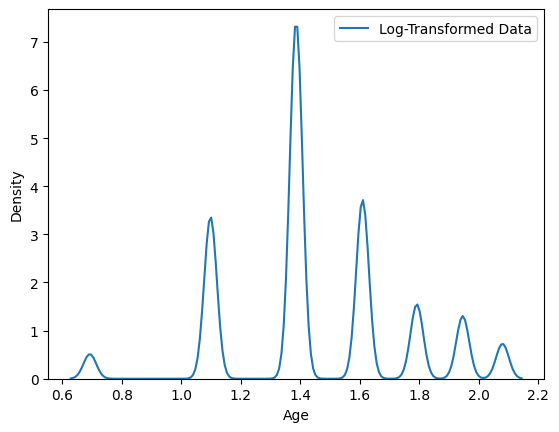

In [137]:
sns.kdeplot(x_train['Age'], label='Original Data')
plt.legend()
plt.show()
sns.kdeplot(data1, label='Log-Transformed Data')
plt.legend()
plt.show()

In [138]:
df=pd.DataFrame(data1)
print(df.skew())

Age   -0.000456
dtype: float64
